# VISEM Tracking — trayectorias reales y preparación YOLO

Este notebook trabaja el proyecto en dos partes:

1. Cargar el dataset VISEM-Tracking.
2. Usar las anotaciones correctas para tracking: `labels_ftid`.
3. Parsear las anotaciones con formato `track_id class_id x_center y_center width height`.
4. Construir una tabla de trayectorias reales para espermatozoides.
5. Graficar trayectorias reales usando los tracking IDs del dataset.
6. Preparar un dataset YOLO de detección de `sperm` quitando el `track_id` de las etiquetas.

La parte de YOLO de este notebook **solo prepara el dataset de detección**. El entrenamiento queda como celda opcional desactivada, para que no se lance accidentalmente al ejecutar todo.


## 0. Instalación e imports

In [1]:
# En Kaggle la mayoría de estas librerías ya vienen instaladas.
!pip -q install tqdm pandas numpy matplotlib opencv-python pyyaml

In [2]:
from pathlib import Path
import os
import re
import json
import math
import shutil
import zipfile
import subprocess
from collections import defaultdict

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython.display import display, Image, Video

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Entorno listo.")

Entorno listo.


## 1. Configuración del proyecto y dataset

In [3]:
# Rutas principales de Kaggle
KAGGLE_INPUT_DIR = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

# Carpeta propia del proyecto
PROJECT_DIR = WORK_DIR / "visem_tracking_project"
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
VIDEOS_OUT_DIR = OUTPUT_DIR / "videos"

for directory in [PROJECT_DIR, DATA_DIR, OUTPUT_DIR, TABLES_DIR, FIGURES_DIR, VIDEOS_OUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Descarga oficial. Solo se usa si no agregaste el dataset desde Kaggle Add Data.
ZENODO_URL = "https://zenodo.org/records/7293726/files/VISEM-Tracking.zip?download=1"
ZIP_PATH = DATA_DIR / "VISEM-Tracking.zip"
EXTRACT_DIR = DATA_DIR / "VISEM-Tracking"

# Cambia a False si no quieres que intente descargar el dataset automáticamente.
ALLOW_DOWNLOAD_IF_MISSING = True

CLASS_NAMES = {
    0: "sperm",
    1: "cluster",
    2: "small_or_pinhead",
}

TARGET_CLASS_ID = 0
TARGET_CLASS_NAME = CLASS_NAMES[TARGET_CLASS_ID]

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv"}

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Clase objetivo inicial:", TARGET_CLASS_ID, TARGET_CLASS_NAME)

PROJECT_DIR: /kaggle/working/visem_tracking_project
OUTPUT_DIR: /kaggle/working/visem_tracking_project/outputs
Clase objetivo inicial: 0 sperm


In [4]:
def find_visem_root(search_dirs):
    """Busca la carpeta VISEM_Tracking_Train_v4 dentro de varias rutas."""
    candidates = []

    for base in search_dirs:
        base = Path(base)
        if not base.exists():
            continue

        exact_matches = list(base.glob("**/VISEM_Tracking_Train_v4"))
        candidates.extend([p for p in exact_matches if p.is_dir()])

        visem_like = [p for p in base.glob("**/*VISEM*") if p.is_dir()]
        candidates.extend([p for p in visem_like if p.is_dir()])

    # Quitar duplicados
    candidates = sorted(set(candidates), key=lambda p: len(str(p)))

    exact = [p for p in candidates if p.name == "VISEM_Tracking_Train_v4"]
    if exact:
        return exact[0]

    return candidates[0] if candidates else None


def download_and_extract_visem():
    """Descarga y descomprime VISEM-Tracking si no está en Kaggle Input."""
    if not ZIP_PATH.exists():
        print("Descargando VISEM-Tracking desde Zenodo...")
        subprocess.run(["wget", "-q", "-c", "-O", str(ZIP_PATH), ZENODO_URL], check=True)
        print("Descarga finalizada:", ZIP_PATH)
    else:
        print("ZIP ya existe:", ZIP_PATH)

    if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.iterdir()):
        print("Descomprimiendo dataset...")
        EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print("Descompresión finalizada:", EXTRACT_DIR)
    else:
        print("Dataset ya descomprimido en:", EXTRACT_DIR)

    return find_visem_root([EXTRACT_DIR])


DATASET_ROOT = find_visem_root([KAGGLE_INPUT_DIR, DATA_DIR])

if DATASET_ROOT is None:
    print("No se encontró el dataset en /kaggle/input ni en data local.")
    if ALLOW_DOWNLOAD_IF_MISSING:
        DATASET_ROOT = download_and_extract_visem()
    else:
        raise FileNotFoundError("Agrega VISEM-Tracking desde Kaggle Add Data o habilita la descarga.")

if DATASET_ROOT is None:
    raise FileNotFoundError("No fue posible encontrar DATASET_ROOT después de la descarga/extracción.")

print("DATASET_ROOT:", DATASET_ROOT)

No se encontró el dataset en /kaggle/input ni en data local.
Descargando VISEM-Tracking desde Zenodo...
Descarga finalizada: /kaggle/working/visem_tracking_project/data/VISEM-Tracking.zip
Descomprimiendo dataset...
Descompresión finalizada: /kaggle/working/visem_tracking_project/data/VISEM-Tracking
DATASET_ROOT: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4


## 2. Ubicar archivos útiles para tracking

In [5]:
# Fuente principal para tracking real:
# labels_ftid/*.txt con formato:
# track_id class_id x_center y_center width height

labels_ftid_files = sorted(DATASET_ROOT.glob("**/labels_ftid/*.txt"))
labels_yolo_files = sorted(DATASET_ROOT.glob("**/labels/*.txt"))
all_videos = sorted([p for p in DATASET_ROOT.rglob("*") if p.suffix.lower() in VIDEO_EXTS])
all_images = sorted([p for p in DATASET_ROOT.rglob("*") if p.suffix.lower() in IMAGE_EXTS])

print("Archivos labels_ftid encontrados:", len(labels_ftid_files))
print("Labels YOLO normales encontrados:", len(labels_yolo_files))
print("Videos encontrados:", len(all_videos))
print("Imágenes encontradas:", len(all_images))

if len(labels_ftid_files) == 0:
    raise FileNotFoundError("No se encontraron archivos labels_ftid. Revisa DATASET_ROOT.")

print("\nEjemplos labels_ftid:")
for p in labels_ftid_files[:5]:
    print("-", p)

Archivos labels_ftid encontrados: 29196
Labels YOLO normales encontrados: 29196
Videos encontrados: 20
Imágenes encontradas: 29370

Ejemplos labels_ftid:
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_with_ftid.txt
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1000_with_ftid.txt
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1001_with_ftid.txt
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1002_with_ftid.txt
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1003_with_ftid.txt


In [6]:
def infer_video_id_from_path(path):
    """Para .../Train/11/labels_ftid/11_frame_0.txt devuelve '11'."""
    path = Path(path)

    if path.parent.name == "labels_ftid":
        return path.parent.parent.name

    nums = re.findall(r"\d+", path.stem)
    return nums[0] if nums else path.parent.name


def infer_frame_number_from_path(path):
    """Para 11_frame_0.txt devuelve 0."""
    path = Path(path)

    match = re.search(r"frame[_\-]?(\d+)", path.stem, re.IGNORECASE)
    if match:
        return int(match.group(1))

    nums = re.findall(r"\d+", path.stem)
    if len(nums) >= 2:
        return int(nums[-1])
    if len(nums) == 1:
        return int(nums[0])

    return np.nan


def find_frame_image_for_label(label_path):
    """Busca la imagen correspondiente a un label_ftid usando el mismo stem."""
    label_path = Path(label_path)
    video_dir = label_path.parent.parent
    stem = label_path.stem

    for image_dir_name in ["images", "imgs", "frames"]:
        image_dir = video_dir / image_dir_name
        if image_dir.exists():
            for ext in IMAGE_EXTS:
                candidate = image_dir / f"{stem}{ext}"
                if candidate.exists():
                    return candidate

    # Fallback: buscar en todo el folder del video
    for ext in IMAGE_EXTS:
        matches = list(video_dir.glob(f"**/{stem}{ext}"))
        if matches:
            return matches[0]

    return None


def valid_yolo_box(x, y, w, h):
    return 0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1

## 3. Parsear anotaciones reales con tracking ID

In [7]:
track_rows = []
bad_rows = []

for txt_path in tqdm(labels_ftid_files, desc="Parseando labels_ftid"):
    video_id = infer_video_id_from_path(txt_path)
    frame_number = infer_frame_number_from_path(txt_path)

    with open(txt_path, "r", errors="ignore") as f:
        for line_number, line in enumerate(f, start=1):
            raw = line.strip()

            if raw == "":
                continue

            parts = raw.split()

            if len(parts) != 6:
                bad_rows.append({
                    "txt_path": str(txt_path),
                    "line_number": line_number,
                    "raw_line": raw,
                    "reason": f"columnas={len(parts)}"
                })
                continue

            try:
                track_id = parts[0]
                class_id = int(float(parts[1]))
                x_center = float(parts[2])
                y_center = float(parts[3])
                width = float(parts[4])
                height = float(parts[5])

                if class_id not in CLASS_NAMES:
                    raise ValueError("class_id fuera de CLASS_NAMES")

                if not valid_yolo_box(x_center, y_center, width, height):
                    raise ValueError("bbox YOLO inválida")

                track_rows.append({
                    "video_id": str(video_id),
                    "frame_number": int(frame_number),
                    "txt_path": str(txt_path),
                    "line_number": line_number,
                    "track_id": track_id,
                    "track_uid": f"{video_id}__{track_id}",
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": width,
                    "height": height,
                    "area_norm": width * height,
                })

            except Exception as e:
                bad_rows.append({
                    "txt_path": str(txt_path),
                    "line_number": line_number,
                    "raw_line": raw,
                    "reason": str(e)
                })

track_ann_df = pd.DataFrame(track_rows)
bad_track_rows_df = pd.DataFrame(bad_rows)

track_ann_df = track_ann_df.sort_values(
    ["video_id", "frame_number", "track_id"]
).reset_index(drop=True)

print("Anotaciones válidas con track_id:", len(track_ann_df))
print("Filas problemáticas:", len(bad_track_rows_df))

display(track_ann_df.head())

if len(bad_track_rows_df) > 0:
    display(bad_track_rows_df.head())

Parseando labels_ftid:   0%|          | 0/29196 [00:00<?, ?it/s]

Anotaciones válidas con track_id: 656335
Filas problemáticas: 0


,video_id,frame_number,txt_path,line_number,track_id,track_uid,class_id,class_name,x_center,y_center,width,height,area_norm
0,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,1,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,0,sperm,0.275781,0.412500,0.026562,0.0375,0.000996
1,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,2,ckz6ru2eb0001386lefk6js4m,11__ckz6ru2eb0001386lefk6js4m,0,sperm,0.238281,0.583333,0.026562,0.0375,0.000996
2,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,3,ckz6ru3um0003386l39xwv0yk,11__ckz6ru3um0003386l39xwv0yk,0,sperm,0.246094,0.847917,0.026562,0.0375,0.000996
3,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,4,ckz6ru5610005386l8uoys4lc,11__ckz6ru5610005386l8uoys4lc,0,sperm,0.194531,0.845833,0.026562,0.0375,0.000996
4,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,5,ckz6ru6of0007386lhf2t4dtw,11__ckz6ru6of0007386lhf2t4dtw,0,sperm,0.083594,0.806250,0.026562,0.0375,0.000996


## 4. Resúmenes de calidad del dataset

In [8]:
print("Conteo por clase:")
class_counts = (
    track_ann_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="n_annotations")
)
class_counts["percentage"] = class_counts["n_annotations"] / class_counts["n_annotations"].sum() * 100
display(class_counts)

print("Frames anotados por video:")
frames_by_video = (
    track_ann_df
    .groupby("video_id")
    .agg(
        n_annotated_frames=("frame_number", "nunique"),
        first_frame=("frame_number", "min"),
        last_frame=("frame_number", "max"),
        n_annotations=("track_id", "count"),
        n_unique_tracks_all_classes=("track_uid", "nunique")
    )
    .reset_index()
    .sort_values("video_id")
)
display(frames_by_video)

print("Clases por video:")
class_by_video = (
    track_ann_df
    .groupby(["video_id", "class_name"])
    .size()
    .reset_index(name="n_annotations")
    .pivot_table(index="video_id", columns="class_name", values="n_annotations", fill_value=0)
    .reset_index()
)
display(class_by_video)

Conteo por clase:


,class_name,n_annotations,percentage
0,sperm,612377,93.302506
1,small_or_pinhead,22112,3.369011
2,cluster,21846,3.328483


Frames anotados por video:


,video_id,n_annotated_frames,first_frame,last_frame,n_annotations,n_unique_tracks_all_classes
0,11,1470,0,1469,56568,57
1,12,1470,0,1469,39357,117
2,13,1470,0,1469,62646,78
3,14,1470,0,1469,5750,8
4,15,1470,0,1469,25215,42
5,19,1470,0,1469,33010,51
6,21,1470,0,1469,32510,80
7,22,1470,0,1469,15983,37
8,23,1296,0,1469,3227,11
9,24,1470,0,1469,97476,111


Clases por video:


class_name,video_id,cluster,small_or_pinhead,sperm
0,11,2714.0,0.0,53854.0
1,12,1470.0,3404.0,34483.0
2,13,0.0,1470.0,61176.0
3,14,721.0,0.0,5029.0
4,15,778.0,778.0,23659.0
5,19,5880.0,173.0,26957.0
6,21,0.0,2954.0,29556.0
7,22,0.0,0.0,15983.0
8,23,0.0,365.0,2862.0
9,24,5880.0,0.0,91596.0


In [9]:
# Guardar tablas principales de auditoría
track_ann_df.to_csv(TABLES_DIR / "tracking_annotations_all_classes.csv", index=False)
class_counts.to_csv(TABLES_DIR / "class_counts_tracking_annotations.csv", index=False)
frames_by_video.to_csv(TABLES_DIR / "frames_by_video_tracking_annotations.csv", index=False)
class_by_video.to_csv(TABLES_DIR / "class_by_video_tracking_annotations.csv", index=False)

if len(bad_track_rows_df) > 0:
    bad_track_rows_df.to_csv(TABLES_DIR / "bad_tracking_annotation_rows.csv", index=False)

print("Tablas de auditoría guardadas en:", TABLES_DIR)

Tablas de auditoría guardadas en: /kaggle/working/visem_tracking_project/outputs/tables


## 5. Construir trayectorias reales de espermatozoides

In [10]:
# Para el objetivo actual usamos solo espermatozoides individuales.
# Los clusters y small_or_pinhead se conservan en track_ann_df, pero no son el foco de trayectorias inicial.

sperm_ann_df = track_ann_df[track_ann_df["class_id"] == TARGET_CLASS_ID].copy()

trajectory_df = (
    sperm_ann_df[
        [
            "video_id",
            "track_id",
            "track_uid",
            "frame_number",
            "x_center",
            "y_center",
            "width",
            "height",
            "area_norm",
            "txt_path",
        ]
    ]
    .sort_values(["video_id", "track_id", "frame_number"])
    .reset_index(drop=True)
)

print("Puntos de trayectoria para sperm:", len(trajectory_df))
display(trajectory_df.head())

Puntos de trayectoria para sperm: 612377


,video_id,track_id,track_uid,frame_number,x_center,y_center,width,height,area_norm,txt_path
0,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,0,0.275781,0.412500,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...
1,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,1,0.275767,0.412549,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1_w...
2,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,2,0.275754,0.412598,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_2_w...
3,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,3,0.275740,0.412647,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_3_w...
4,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,4,0.275726,0.412697,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_4_w...


In [11]:
# Resumen por trayectoria
track_summary = (
    trajectory_df
    .groupby(["video_id", "track_id", "track_uid"])
    .agg(
        n_frames=("frame_number", "nunique"),
        first_frame=("frame_number", "min"),
        last_frame=("frame_number", "max"),
        mean_x=("x_center", "mean"),
        mean_y=("y_center", "mean"),
        mean_area=("area_norm", "mean"),
    )
    .reset_index()
)

track_summary["duration_span"] = track_summary["last_frame"] - track_summary["first_frame"] + 1
track_summary["coverage"] = track_summary["n_frames"] / track_summary["duration_span"]

print("Tracks únicos de sperm:", len(track_summary))
display(track_summary["n_frames"].describe())

thresholds = [2, 5, 10, 15, 30, 50, 100, 300, 500]
track_duration_summary = pd.DataFrame([
    {
        "min_frames": t,
        "n_tracks": int((track_summary["n_frames"] >= t).sum()),
        "percentage": float((track_summary["n_frames"] >= t).mean() * 100),
    }
    for t in thresholds
])

print("Trayectorias disponibles según duración mínima:")
display(track_duration_summary)

print("Resumen por video:")
tracks_by_video = (
    track_summary
    .groupby("video_id")
    .agg(
        n_unique_sperm=("track_uid", "nunique"),
        mean_track_length=("n_frames", "mean"),
        median_track_length=("n_frames", "median"),
        max_track_length=("n_frames", "max"),
        mean_coverage=("coverage", "mean"),
    )
    .reset_index()
    .sort_values("video_id")
)
display(tracks_by_video)

Tracks únicos de sperm: 1121


count    1121.000000
mean      546.277431
std       503.084708
min         1.000000
25%       106.000000
50%       383.000000
75%       782.000000
max      1470.000000
Name: n_frames, dtype: float64

Trayectorias disponibles según duración mínima:


,min_frames,n_tracks,percentage
0,2,1116,99.553970
1,5,1103,98.394291
2,10,1083,96.610169
3,15,1063,94.826048
4,30,963,85.905442
5,50,920,82.069581
6,100,849,75.735950
7,300,617,55.040143
8,500,465,41.480821


Resumen por video:


,video_id,n_unique_sperm,mean_track_length,median_track_length,max_track_length,mean_coverage
0,11,55,979.163636,1283.0,1470,0.997661
1,12,111,310.657658,156.0,1470,0.990600
2,13,77,794.493506,756.0,1470,0.997225
3,14,7,718.428571,721.0,749,0.977618
4,15,40,591.475000,778.0,778,1.000000
5,19,46,586.021739,309.5,1470,1.000000
6,21,75,394.080000,373.0,753,1.000000
7,22,37,431.972973,144.0,1470,0.998713
8,23,8,357.750000,228.5,755,1.000000
9,24,107,856.037383,1076.0,1470,0.997770


In [12]:
# Guardar tablas de trayectorias
trajectory_df.to_csv(TABLES_DIR / "sperm_trajectory_points.csv", index=False)
track_summary.to_csv(TABLES_DIR / "sperm_track_summary.csv", index=False)
track_duration_summary.to_csv(TABLES_DIR / "sperm_track_duration_thresholds.csv", index=False)
tracks_by_video.to_csv(TABLES_DIR / "sperm_tracks_by_video.csv", index=False)

print("Tablas de trayectorias guardadas en:", TABLES_DIR)

Tablas de trayectorias guardadas en: /kaggle/working/visem_tracking_project/outputs/tables


## 6. Filtrar trayectorias útiles para análisis de movimiento

In [13]:
# Puedes ajustar estos umbrales más adelante.
MIN_TRACK_FRAMES = 30
MIN_TRACK_COVERAGE = 0.30

usable_track_uids = track_summary[
    (track_summary["n_frames"] >= MIN_TRACK_FRAMES) &
    (track_summary["coverage"] >= MIN_TRACK_COVERAGE)
]["track_uid"].tolist()

usable_trajectory_df = trajectory_df[
    trajectory_df["track_uid"].isin(usable_track_uids)
].copy()

usable_track_summary = track_summary[
    track_summary["track_uid"].isin(usable_track_uids)
].copy()

print("Umbral mínimo de frames:", MIN_TRACK_FRAMES)
print("Cobertura mínima:", MIN_TRACK_COVERAGE)
print("Tracks útiles:", len(usable_track_summary))
print("Puntos de trayectoria útiles:", len(usable_trajectory_df))

display(usable_track_summary.head())

usable_trajectory_df.to_csv(TABLES_DIR / "usable_sperm_trajectory_points.csv", index=False)
usable_track_summary.to_csv(TABLES_DIR / "usable_sperm_track_summary.csv", index=False)

Umbral mínimo de frames: 30
Cobertura mínima: 0.3
Tracks útiles: 962
Puntos de trayectoria útiles: 609497


,video_id,track_id,track_uid,n_frames,first_frame,last_frame,mean_x,mean_y,mean_area,duration_span,coverage
0,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,1470,0,1469,0.267312,0.431563,0.000996,1470,1.0
1,11,ckz6ru2eb0001386lefk6js4m,11__ckz6ru2eb0001386lefk6js4m,1470,0,1469,0.238281,0.577538,0.000996,1470,1.0
2,11,ckz6ru3um0003386l39xwv0yk,11__ckz6ru3um0003386l39xwv0yk,1470,0,1469,0.241859,0.855643,0.000996,1470,1.0
3,11,ckz6ru5610005386l8uoys4lc,11__ckz6ru5610005386l8uoys4lc,1470,0,1469,0.194531,0.845833,0.000996,1470,1.0
4,11,ckz6ru6of0007386lhf2t4dtw,11__ckz6ru6of0007386lhf2t4dtw,1470,0,1469,0.083594,0.806250,0.000996,1470,1.0


## 7. Visualización rápida de trayectorias

Video de ejemplo: 36
Figura guardada en: /kaggle/working/visem_tracking_project/outputs/figures/trajectories_video_36.png


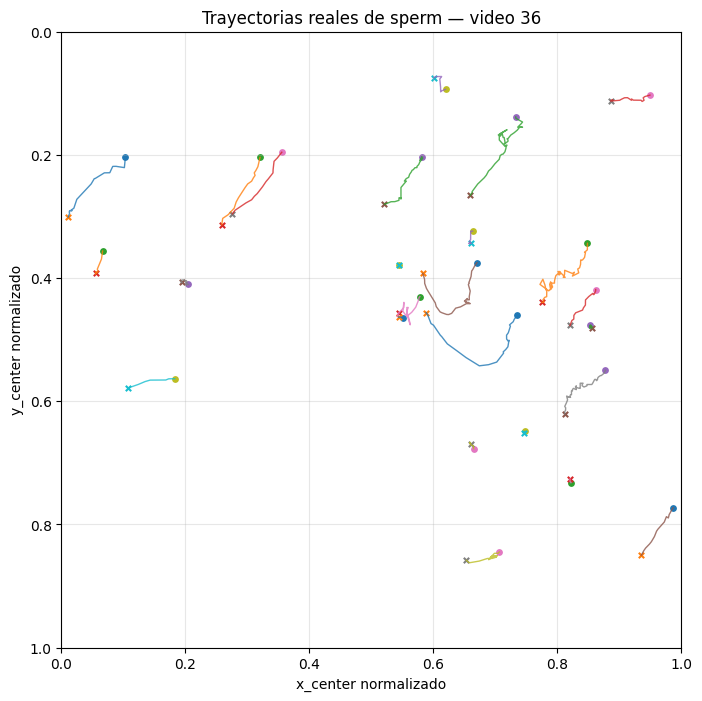

PosixPath('/kaggle/working/visem_tracking_project/outputs/figures/trajectories_video_36.png')

In [14]:
def plot_tracks_for_video(video_id, max_tracks=20, min_frames=30, save=True):
    """Grafica trayectorias normalizadas para un video."""
    video_tracks = track_summary[
        (track_summary["video_id"] == str(video_id)) &
        (track_summary["n_frames"] >= min_frames)
    ].sort_values("n_frames", ascending=False)

    selected_uids = video_tracks["track_uid"].head(max_tracks).tolist()
    plot_df = trajectory_df[trajectory_df["track_uid"].isin(selected_uids)]

    if plot_df.empty:
        print(f"No hay trayectorias para video {video_id} con min_frames={min_frames}.")
        return None

    plt.figure(figsize=(8, 8))

    for track_uid, group in plot_df.groupby("track_uid"):
        group = group.sort_values("frame_number")
        plt.plot(group["x_center"], group["y_center"], linewidth=1, alpha=0.8)
        plt.scatter(group["x_center"].iloc[0], group["y_center"].iloc[0], s=15, marker="o")
        plt.scatter(group["x_center"].iloc[-1], group["y_center"].iloc[-1], s=15, marker="x")

    plt.gca().invert_yaxis()
    plt.xlim(0, 1)
    plt.ylim(1, 0)
    plt.xlabel("x_center normalizado")
    plt.ylabel("y_center normalizado")
    plt.title(f"Trayectorias reales de sperm — video {video_id}")
    plt.grid(True, alpha=0.3)

    out_path = FIGURES_DIR / f"trajectories_video_{video_id}.png"

    if save:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Figura guardada en:", out_path)

    plt.show()
    return out_path


# Elegir automáticamente un video con muchas trayectorias largas
example_video_id = (
    tracks_by_video
    .sort_values(["n_unique_sperm", "median_track_length"], ascending=False)
    .iloc[0]["video_id"]
)

print("Video de ejemplo:", example_video_id)
plot_tracks_for_video(example_video_id, max_tracks=25, min_frames=50)

Track más largo: 11__ckz6ruchb000f386lxxpeu5na
Figura guardada en: /kaggle/working/visem_tracking_project/outputs/figures/single_track_video_11_ckz6ruchb000f386lxxpeu5na.png


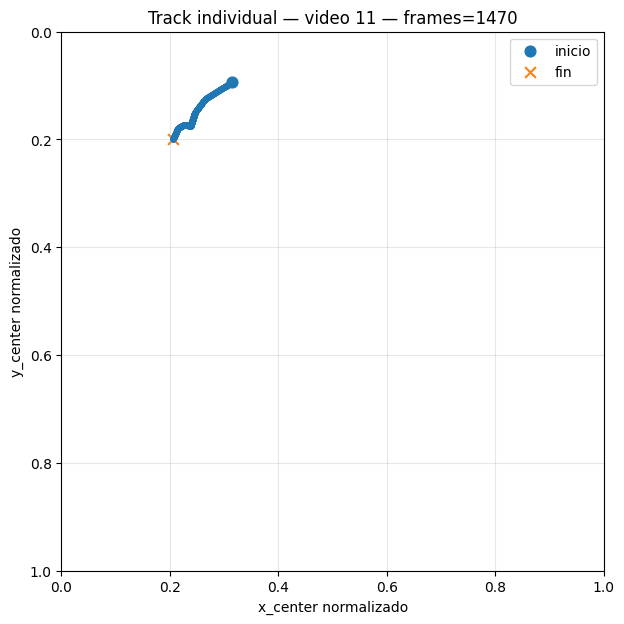

PosixPath('/kaggle/working/visem_tracking_project/outputs/figures/single_track_video_11_ckz6ruchb000f386lxxpeu5na.png')

In [15]:
def plot_single_track(track_uid, save=True):
    """Grafica una trayectoria individual."""
    group = trajectory_df[trajectory_df["track_uid"] == track_uid].sort_values("frame_number")

    if group.empty:
        print("No existe track_uid:", track_uid)
        return None

    video_id = group["video_id"].iloc[0]
    track_id = group["track_id"].iloc[0]

    plt.figure(figsize=(7, 7))
    plt.plot(group["x_center"], group["y_center"], marker=".", linewidth=1)
    plt.scatter(group["x_center"].iloc[0], group["y_center"].iloc[0], s=60, marker="o", label="inicio")
    plt.scatter(group["x_center"].iloc[-1], group["y_center"].iloc[-1], s=60, marker="x", label="fin")

    plt.gca().invert_yaxis()
    plt.xlim(0, 1)
    plt.ylim(1, 0)
    plt.xlabel("x_center normalizado")
    plt.ylabel("y_center normalizado")
    plt.title(f"Track individual — video {video_id} — frames={len(group)}")
    plt.grid(True, alpha=0.3)
    plt.legend()

    safe_track_id = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(track_id))[:80]
    out_path = FIGURES_DIR / f"single_track_video_{video_id}_{safe_track_id}.png"

    if save:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Figura guardada en:", out_path)

    plt.show()
    return out_path


# Graficar el track más largo como ejemplo
longest_track_uid = track_summary.sort_values("n_frames", ascending=False).iloc[0]["track_uid"]
print("Track más largo:", longest_track_uid)
plot_single_track(longest_track_uid)

## 8. Revisar trayectoria sobre un frame real

In [16]:
def yolo_to_pixel_box(x, y, w, h, image_width, image_height):
    """Convierte bbox YOLO normalizada a x1, y1, x2, y2 en píxeles."""
    x1 = int((x - w / 2) * image_width)
    y1 = int((y - h / 2) * image_height)
    x2 = int((x + w / 2) * image_width)
    y2 = int((y + h / 2) * image_height)

    x1 = max(0, min(x1, image_width - 1))
    x2 = max(0, min(x2, image_width - 1))
    y1 = max(0, min(y1, image_height - 1))
    y2 = max(0, min(y2, image_height - 1))

    return x1, y1, x2, y2


def draw_tracks_on_frame(video_id, frame_number=None, max_tracks=30, history_frames=100, save=True):
    """Dibuja cajas y trazas recientes sobre un frame real."""
    video_id = str(video_id)

    video_points = trajectory_df[trajectory_df["video_id"] == video_id]

    if video_points.empty:
        print("No hay puntos para video:", video_id)
        return None

    if frame_number is None:
        frame_number = int(video_points["frame_number"].median())

    frame_points = video_points[video_points["frame_number"] == frame_number].copy()

    if frame_points.empty:
        print(f"No hay anotaciones en video {video_id}, frame {frame_number}.")
        return None

    # Buscar imagen correspondiente desde uno de los txt_path del frame
    label_path = Path(frame_points["txt_path"].iloc[0])
    image_path = find_frame_image_for_label(label_path)

    if image_path is None:
        print("No se encontró imagen para:", label_path)
        return None

    img = cv2.imread(str(image_path))

    if img is None:
        print("No se pudo leer imagen:", image_path)
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = img.shape[:2]

    # Tomar tracks más largos presentes en ese frame
    present_uids = frame_points["track_uid"].unique().tolist()
    selected_uids = (
        track_summary[track_summary["track_uid"].isin(present_uids)]
        .sort_values("n_frames", ascending=False)
        .head(max_tracks)["track_uid"]
        .tolist()
    )

    canvas = img.copy()

    for track_uid in selected_uids:
        current = frame_points[frame_points["track_uid"] == track_uid].iloc[0]

        x1, y1, x2, y2 = yolo_to_pixel_box(
            current["x_center"],
            current["y_center"],
            current["width"],
            current["height"],
            w_img,
            h_img
        )

        cv2.rectangle(canvas, (x1, y1), (x2, y2), (255, 255, 255), 1)

        hist = trajectory_df[
            (trajectory_df["track_uid"] == track_uid) &
            (trajectory_df["frame_number"] <= frame_number) &
            (trajectory_df["frame_number"] >= frame_number - history_frames)
        ].sort_values("frame_number")

        pts = []
        for _, row in hist.iterrows():
            px = int(row["x_center"] * w_img)
            py = int(row["y_center"] * h_img)
            pts.append((px, py))

        if len(pts) >= 2:
            for p1, p2 in zip(pts[:-1], pts[1:]):
                cv2.line(canvas, p1, p2, (255, 255, 255), 1)

    plt.figure(figsize=(10, 8))
    plt.imshow(canvas)
    plt.axis("off")
    plt.title(f"Video {video_id} — frame {frame_number} — trazas recientes")

    out_path = FIGURES_DIR / f"tracks_overlay_video_{video_id}_frame_{frame_number}.png"

    if save:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Figura guardada en:", out_path)

    plt.show()
    return out_path


draw_tracks_on_frame(example_video_id, frame_number=None, max_tracks=30, history_frames=100)

No se encontró imagen para: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/36/labels_ftid/36_frame_719_with_ftid.txt


## 9. Exportar resultados

In [17]:
# Crear un ZIP con tablas y figuras generadas
zip_path = WORK_DIR / "visem_tracking_ground_truth_outputs.zip"

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(
    base_name=str(zip_path).replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_DIR
)

print("ZIP generado:", zip_path)
print("Contenido principal:")
print("-", TABLES_DIR / "tracking_annotations_all_classes.csv")
print("-", TABLES_DIR / "sperm_trajectory_points.csv")
print("-", TABLES_DIR / "usable_sperm_trajectory_points.csv")
print("-", FIGURES_DIR)

ZIP generado: /kaggle/working/visem_tracking_ground_truth_outputs.zip
Contenido principal:
- /kaggle/working/visem_tracking_project/outputs/tables/tracking_annotations_all_classes.csv
- /kaggle/working/visem_tracking_project/outputs/tables/sperm_trajectory_points.csv
- /kaggle/working/visem_tracking_project/outputs/tables/usable_sperm_trajectory_points.csv
- /kaggle/working/visem_tracking_project/outputs/figures


## Conclusión del Paso 2

En este paso se construyeron trayectorias reales de espermatozoides usando directamente las anotaciones del dataset. Primero se cargaron los archivos `labels_ftid`, se organizó la información en una tabla con video, frame, `track_id`, clase y coordenadas normalizadas de cada bounding box. Luego se filtraron únicamente las anotaciones correspondientes a la clase `sperm`.

A partir de los `track_id`, fue posible agrupar las detecciones de un mismo espermatozoide a lo largo de distintos frames y construir trayectorias reales. Las gráficas generadas muestran que los identificadores de tracking permiten seguir el movimiento de espermatozoides individuales dentro del video.

Este resultado es satisfactorio porque valida que el dataset contiene información útil de tracking y que puede usarse como ground truth para estudiar el movimiento real antes de entrenar o evaluar modelos de detección como YOLO.

El siguiente paso práctico es preparar un dataset YOLO para que el modelo aprenda detección frame por frame. Para eso se usan las mismas anotaciones, pero se elimina el `track_id`, porque YOLO solo necesita: `class x_center y_center width height`.


## 10. Paso 3: preparar dataset YOLO para detección de `sperm`

En esta sección se crea un dataset YOLO normal a partir de las anotaciones `labels_ftid`.

La idea es convertir esto:

```text
track_id class_id x_center y_center width height
```

en esto:

```text
class_id x_center y_center width height
```

Como el primer modelo solo detectará espermatozoides individuales, todas las etiquetas quedan como clase `0: sperm`.

Además, el split se hace por **video**, no por frame, para evitar que frames casi idénticos del mismo video queden mezclados entre entrenamiento y prueba.


In [18]:
from sklearn.model_selection import train_test_split

def natural_sort_key(value):
    value = str(value)
    return (0, int(value)) if value.isdigit() else (1, value)

# Usamos solo videos con anotaciones de sperm.
video_ids = sorted(sperm_ann_df["video_id"].astype(str).unique(), key=natural_sort_key)

if len(video_ids) < 3:
    raise ValueError("Se necesitan al menos 3 videos para crear train/val/test por video.")

train_videos, temp_videos = train_test_split(
    video_ids,
    test_size=0.30,
    random_state=42
)

val_videos, test_videos = train_test_split(
    temp_videos,
    test_size=0.50,
    random_state=42
)

split_by_video = {}

for video_id in train_videos:
    split_by_video[str(video_id)] = "train"

for video_id in val_videos:
    split_by_video[str(video_id)] = "val"

for video_id in test_videos:
    split_by_video[str(video_id)] = "test"

split_summary = pd.DataFrame([
    {"split": "train", "n_videos": len(train_videos), "videos": sorted(map(str, train_videos), key=natural_sort_key)},
    {"split": "val", "n_videos": len(val_videos), "videos": sorted(map(str, val_videos), key=natural_sort_key)},
    {"split": "test", "n_videos": len(test_videos), "videos": sorted(map(str, test_videos), key=natural_sort_key)},
])

display(split_summary)


,split,n_videos,videos
0,train,14,"[13, 14, 15, 21, 22, 24, 29, 30, 35, 36, 38, 52, 60, 82]"
1,val,3,"[12, 23, 47]"
2,test,3,"[11, 19, 54]"


In [19]:
# Carpeta de salida para el dataset YOLO de detección.
YOLO_DATASET_DIR = PROJECT_DIR / "yolo_sperm_dataset"
YAML_PATH = YOLO_DATASET_DIR / "data.yaml"

# Se borra la versión anterior para evitar quedarnos con carpetas vacías o archivos viejos.
if YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)

for split in ["train", "val", "test"]:
    (YOLO_DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Dataset YOLO será creado en:")
print(YOLO_DATASET_DIR)


Dataset YOLO será creado en:
/kaggle/working/visem_tracking_project/yolo_sperm_dataset


In [20]:
# Índices robustos de imágenes y videos.
# Esto permite que el notebook funcione si el dataset trae frames como imágenes
# o si solo trae videos y toca extraer los frames con OpenCV.

known_video_ids = set(video_ids)

def infer_media_video_id(path):
    path = Path(path)

    # Caso más confiable: alguna carpeta del path es el número del video.
    for part in reversed(path.parts):
        if part in known_video_ids:
            return str(part)

    # Fallback: buscar números en el nombre del archivo.
    nums = re.findall(r"\d+", path.stem)
    for num in nums:
        if num in known_video_ids:
            return str(num)

    return None


def infer_media_frame_number(path):
    path = Path(path)
    stem = path.stem

    match = re.search(r"frame[_\-]?0*(\d+)", stem, re.IGNORECASE)
    if match:
        return int(match.group(1))

    nums = re.findall(r"\d+", stem)
    if nums:
        return int(nums[-1])

    return None


all_images = sorted([
    p for p in Path(DATASET_ROOT).rglob("*")
    if p.suffix.lower() in IMAGE_EXTS
])

all_video_files = sorted([
    p for p in Path(DATASET_ROOT).rglob("*")
    if p.suffix.lower() in VIDEO_EXTS
])

image_index = {}

for image_path in all_images:
    video_id = infer_media_video_id(image_path)
    frame_number = infer_media_frame_number(image_path)

    if video_id is None or frame_number is None:
        continue

    key = (str(video_id), int(frame_number))

    if key not in image_index:
        image_index[key] = image_path

video_index = {}

for video_path in all_video_files:
    video_id = infer_media_video_id(video_path)

    if video_id is None:
        continue

    if video_id not in video_index:
        video_index[video_id] = video_path

print("Imágenes originales encontradas:", len(all_images))
print("Imágenes indexadas por video/frame:", len(image_index))
print("Videos originales encontrados:", len(all_video_files))
print("Videos indexados por video_id:", len(video_index))

print("\nEjemplos de videos indexados:")
for video_id, video_path in list(sorted(video_index.items(), key=lambda x: natural_sort_key(x[0])))[:10]:
    print(f"- video {video_id}: {video_path}")

print("\nEjemplos de imágenes indexadas:")
for key, image_path in list(image_index.items())[:10]:
    print(f"- {key}: {image_path}")


Imágenes originales encontradas: 29370
Imágenes indexadas por video/frame: 29370
Videos originales encontrados: 20
Videos indexados por video_id: 20

Ejemplos de videos indexados:
- video 11: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4
- video 12: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/12/12.mp4
- video 13: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/13/13.mp4
- video 14: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/14/14.mp4
- video 15: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/15/15.mp4
- video 19: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/19/19.mp4
- video 21: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/21/21.mp4
- video 22: /kaggle/working/visem_tracking_

In [21]:
# Funciones auxiliares para obtener el frame real.
# Si existe imagen, la usa. Si no existe, extrae el frame desde el video.

video_capture_cache = {}

def read_existing_image(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        return None
    return image


def read_video_frame(video_path, frame_number):
    video_path = Path(video_path)

    if str(video_path) not in video_capture_cache:
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            return None
        video_capture_cache[str(video_path)] = cap

    cap = video_capture_cache[str(video_path)]
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_number))
    ok, frame = cap.read()

    if not ok or frame is None:
        return None

    return frame


def get_frame_for_yolo_dataset(video_id, frame_number):
    video_id = str(video_id)
    frame_number = int(frame_number)

    # 1. Intentar con imagen ya existente.
    candidate_frame_numbers = [frame_number, frame_number - 1, frame_number + 1]

    for candidate_frame in candidate_frame_numbers:
        key = (video_id, candidate_frame)
        if key in image_index:
            image = read_existing_image(image_index[key])
            if image is not None:
                return image, "image", candidate_frame

    # 2. Si no hay imagen, intentar extraer desde video.
    if video_id not in video_index:
        return None, "missing_video", None

    video_path = video_index[video_id]

    for candidate_frame in candidate_frame_numbers:
        if candidate_frame < 0:
            continue

        frame = read_video_frame(video_path, candidate_frame)
        if frame is not None:
            return frame, "video", candidate_frame

    return None, "failed_extraction", None


In [22]:
# Crear dataset YOLO:
# - una imagen por frame anotado
# - un .txt por imagen
# - cada línea del .txt queda en formato YOLO normal: class x_center y_center width height

created_images = 0
created_labels = 0
missing_frames = []
source_counter = defaultdict(int)

frame_groups = sperm_ann_df.groupby(["video_id", "frame_number"], sort=True)

for (video_id, frame_number), group in tqdm(frame_groups, desc="Creando dataset YOLO sperm"):
    video_id = str(video_id)
    frame_number = int(frame_number)

    if video_id not in split_by_video:
        continue

    split = split_by_video[video_id]

    output_stem = f"video_{video_id}_frame_{frame_number:06d}"
    output_image_path = YOLO_DATASET_DIR / "images" / split / f"{output_stem}.jpg"
    output_label_path = YOLO_DATASET_DIR / "labels" / split / f"{output_stem}.txt"

    image, source_type, used_frame_number = get_frame_for_yolo_dataset(video_id, frame_number)

    if image is None:
        missing_frames.append({
            "video_id": video_id,
            "frame_number": frame_number,
            "reason": source_type
        })
        continue

    ok = cv2.imwrite(str(output_image_path), image)

    if not ok:
        missing_frames.append({
            "video_id": video_id,
            "frame_number": frame_number,
            "reason": "cv2_imwrite_failed"
        })
        continue

    yolo_lines = []

    for _, row in group.iterrows():
        # Dataset de una sola clase: sperm = 0
        yolo_lines.append(
            f"0 {float(row['x_center']):.6f} {float(row['y_center']):.6f} {float(row['width']):.6f} {float(row['height']):.6f}"
        )

    with open(output_label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    created_images += 1
    created_labels += 1
    source_counter[source_type] += 1

# Liberar videos abiertos por OpenCV
for cap in video_capture_cache.values():
    cap.release()

print("Imágenes creadas:", created_images)
print("Labels creados:", created_labels)
print("Frames no encontrados:", len(missing_frames))
print("Fuente de frames:", dict(source_counter))

if len(missing_frames) > 0:
    missing_frames_df = pd.DataFrame(missing_frames)
    display(missing_frames_df.head(20))
    missing_frames_df.to_csv(TABLES_DIR / "missing_frames_yolo_dataset.csv", index=False)

if created_images == 0:
    raise RuntimeError(
        "No se creó ninguna imagen. Revisa si DATASET_ROOT contiene videos o frames accesibles."
    )


Creando dataset YOLO sperm:   0%|          | 0/28974 [00:00<?, ?it/s]

Imágenes creadas: 28974
Labels creados: 28974
Frames no encontrados: 0
Fuente de frames: {'image': 28974}


In [23]:
# Crear data.yaml para Ultralytics YOLO

data_yaml = {
    "path": str(YOLO_DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "sperm"
    }
}

with open(YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("Archivo YAML creado en:")
print(YAML_PATH)

print("\nContenido:")
print(yaml.dump(data_yaml, sort_keys=False))


Archivo YAML creado en:
/kaggle/working/visem_tracking_project/yolo_sperm_dataset/data.yaml

Contenido:
path: /kaggle/working/visem_tracking_project/yolo_sperm_dataset
train: images/train
val: images/val
test: images/test
names:
  0: sperm



In [24]:
# Verificación final del dataset YOLO

verification_rows = []

for split in ["train", "val", "test"]:
    image_files = sorted((YOLO_DATASET_DIR / "images" / split).glob("*.jpg"))
    label_files = sorted((YOLO_DATASET_DIR / "labels" / split).glob("*.txt"))

    image_stems = {p.stem for p in image_files}
    label_stems = {p.stem for p in label_files}

    verification_rows.append({
        "split": split,
        "images": len(image_files),
        "labels": len(label_files),
        "images_without_label": len(image_stems - label_stems),
        "labels_without_image": len(label_stems - image_stems),
    })

verification_df = pd.DataFrame(verification_rows)
display(verification_df)

if (verification_df["images"] == 0).any():
    raise RuntimeError("Algún split quedó sin imágenes. Revisa el split por video o la extracción de frames.")

if (verification_df["images"] != verification_df["labels"]).any():
    raise RuntimeError("Hay splits con diferente número de imágenes y labels.")

if (verification_df["images_without_label"] > 0).any() or (verification_df["labels_without_image"] > 0).any():
    raise RuntimeError("Hay imágenes sin label o labels sin imagen.")

print("Dataset YOLO verificado correctamente.")


,split,images,labels,images_without_label,labels_without_image
0,train,20550,20550,0,0
1,val,4014,4014,0,0
2,test,4410,4410,0,0


Dataset YOLO verificado correctamente.


Imagen de muestra: /kaggle/working/visem_tracking_project/yolo_sperm_dataset/images/train/video_13_frame_000000.jpg
Label de muestra: /kaggle/working/visem_tracking_project/yolo_sperm_dataset/labels/train/video_13_frame_000000.txt


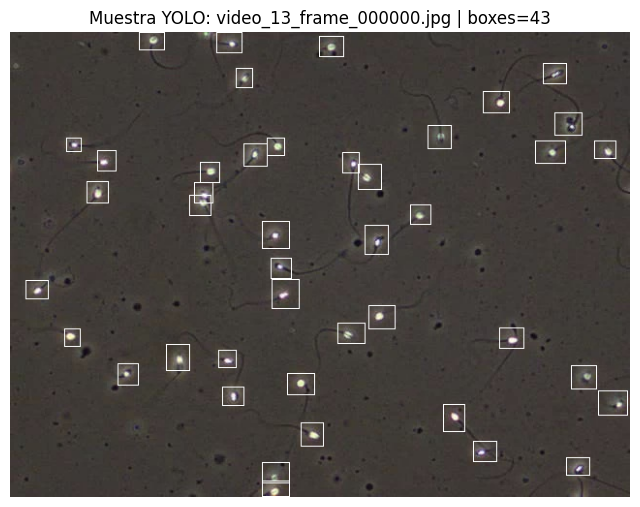

In [25]:
# Visualizar una muestra del dataset YOLO generado

def draw_yolo_boxes_on_image(image_path, label_path, class_names=None, max_boxes=100):
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line in lines[:max_boxes]:
        cls, x_center, y_center, box_w, box_h = line.split()
        cls = int(cls)
        x_center = float(x_center)
        y_center = float(y_center)
        box_w = float(box_w)
        box_h = float(box_h)

        x1 = int((x_center - box_w / 2) * w)
        y1 = int((y_center - box_h / 2) * h)
        x2 = int((x_center + box_w / 2) * w)
        y2 = int((y_center + box_h / 2) * h)

        x1 = max(0, min(x1, w - 1))
        x2 = max(0, min(x2, w - 1))
        y1 = max(0, min(y1, h - 1))
        y2 = max(0, min(y2, h - 1))

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 255, 255), 1)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Muestra YOLO: {image_path.name} | boxes={len(lines)}")
    plt.show()


sample_split = "train"
sample_images = sorted((YOLO_DATASET_DIR / "images" / sample_split).glob("*.jpg"))

if len(sample_images) == 0:
    print("No hay imágenes de muestra en:", sample_split)
else:
    sample_image_path = sample_images[0]
    sample_label_path = YOLO_DATASET_DIR / "labels" / sample_split / f"{sample_image_path.stem}.txt"

    print("Imagen de muestra:", sample_image_path)
    print("Label de muestra:", sample_label_path)

    draw_yolo_boxes_on_image(sample_image_path, sample_label_path, CLASS_NAMES)


## 11. Entrenamiento YOLO opcional

La celda siguiente queda desactivada por defecto. Primero confirma que el dataset YOLO quedó con imágenes y labels en `train`, `val` y `test`.

Cuando ya quieras entrenar, cambia:

```python
RUN_TRAINING = False
```

por:

```python
RUN_TRAINING = True
```


In [ ]:
RUN_TRAINING = True

if RUN_TRAINING:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

    from ultralytics import YOLO

    model = YOLO("yolov8n.pt")

    results = model.train(
        data=str(YAML_PATH),
        epochs=30,
        imgsz=640,
        batch=16,
        patience=8,
        project=str(PROJECT_DIR / "runs"),
        name="sperm_yolov8n_detector",
        pretrained=True
    )
else:
    print("Entrenamiento desactivado. Cambia RUN_TRAINING = True cuando quieras entrenar YOLO.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visem_tracking_project/yolo_sperm_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, flip

In [27]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

RUNS_DIR = PROJECT_DIR / "runs"

train_dirs = sorted(
    [p for p in RUNS_DIR.glob("*") if (p / "results.csv").exists()],
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

if len(train_dirs) == 0:
    raise FileNotFoundError("No se encontró ningún entrenamiento con results.csv.")

BEST_RUN_DIR = train_dirs[0]
BEST_WEIGHTS_PATH = BEST_RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS_PATH = BEST_RUN_DIR / "weights" / "last.pt"

print("Último entrenamiento encontrado:")
print(BEST_RUN_DIR)

print("\nBest weights:")
print(BEST_WEIGHTS_PATH)

print("\nLast weights:")
print(LAST_WEIGHTS_PATH)

print("\n¿Existe best.pt?", BEST_WEIGHTS_PATH.exists())
print("¿Existe last.pt?", LAST_WEIGHTS_PATH.exists())

Último entrenamiento encontrado:
/kaggle/working/visem_tracking_project/runs/sperm_yolov8n_detector

Best weights:
/kaggle/working/visem_tracking_project/runs/sperm_yolov8n_detector/weights/best.pt

Last weights:
/kaggle/working/visem_tracking_project/runs/sperm_yolov8n_detector/weights/last.pt

¿Existe best.pt? True
¿Existe last.pt? True


In [28]:
results_csv = BEST_RUN_DIR / "results.csv"

results_df = pd.read_csv(results_csv)
results_df.columns = results_df.columns.str.strip()

print("Columnas disponibles:")
print(results_df.columns.tolist())

display(results_df.tail())

Columnas disponibles:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
5,6,1510.45,1.14104,0.52021,0.87637,0.65125,0.72252,0.55704,0.17118,2.60196,1.36597,1.34570,0.001670,0.001670,0.001670
6,7,1759.39,1.10448,0.50563,0.87011,0.67728,0.74861,0.58157,0.18314,2.57244,1.32396,1.33048,0.001604,0.001604,0.001604
7,8,2010.21,1.07250,0.49290,0.86458,0.65045,0.72987,0.53517,0.16245,2.66825,1.43709,1.41429,0.001538,0.001538,0.001538
8,9,2259.81,1.04402,0.47986,0.85962,0.63313,0.71233,0.52455,0.15366,2.77541,1.40713,1.46574,0.001472,0.001472,0.001472
9,10,2507.59,1.02347,0.47036,0.85661,0.64427,0.72978,0.53458,0.16123,2.71557,1.45269,1.45288,0.001406,0.001406,0.001406


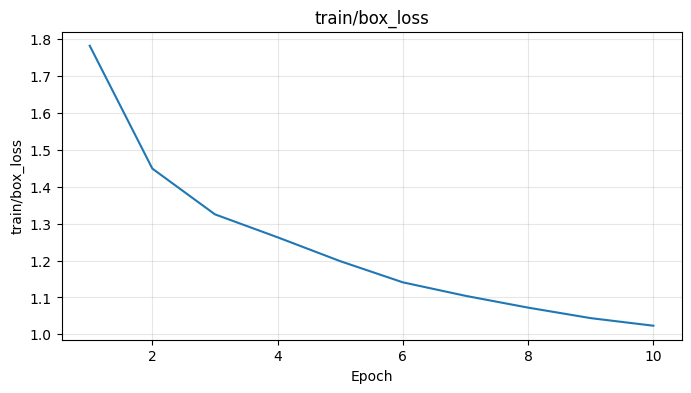

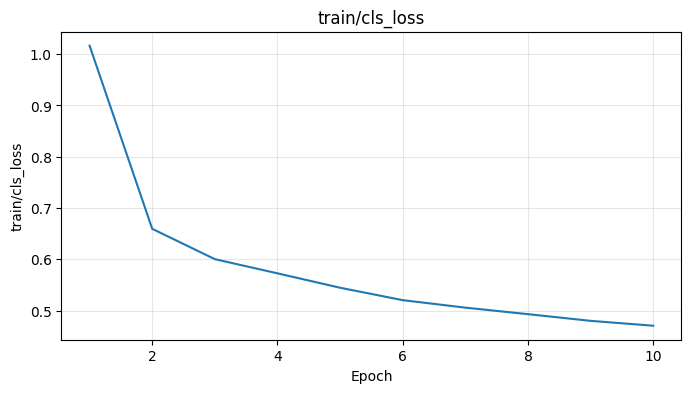

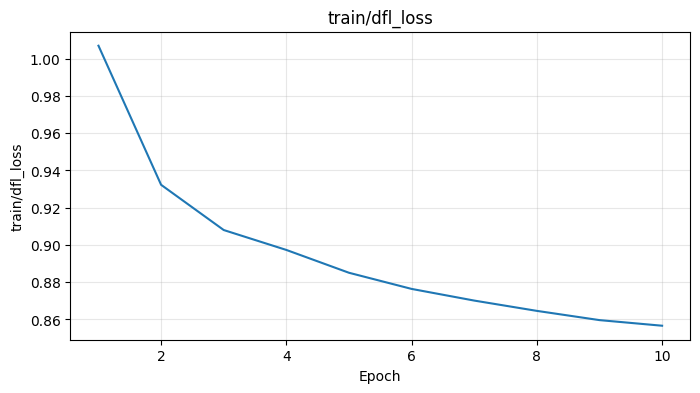

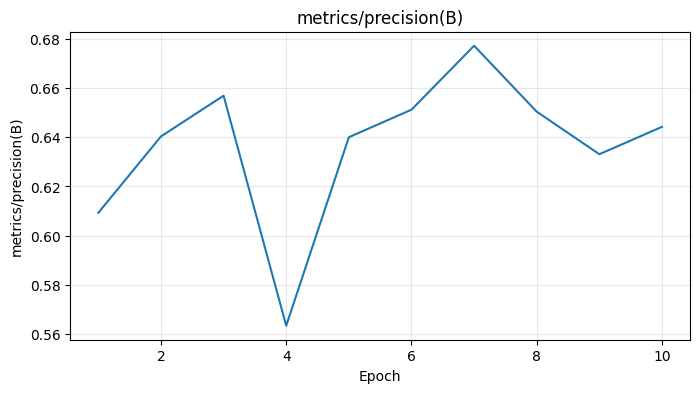

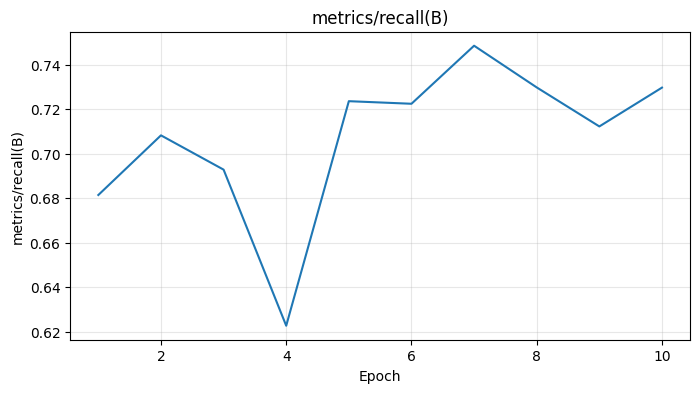

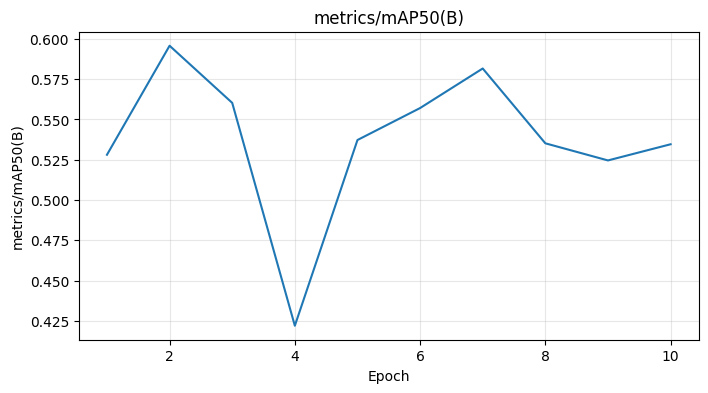

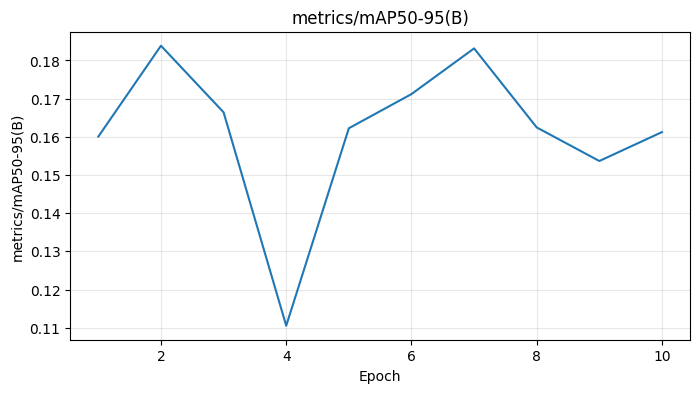

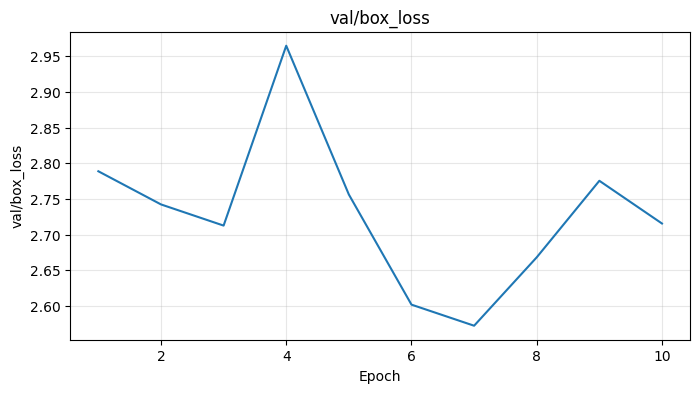

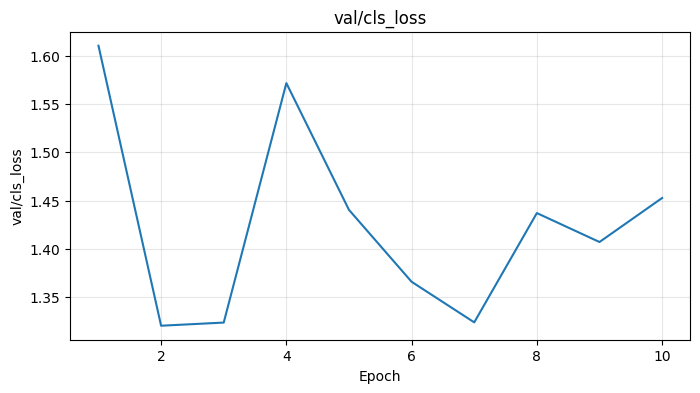

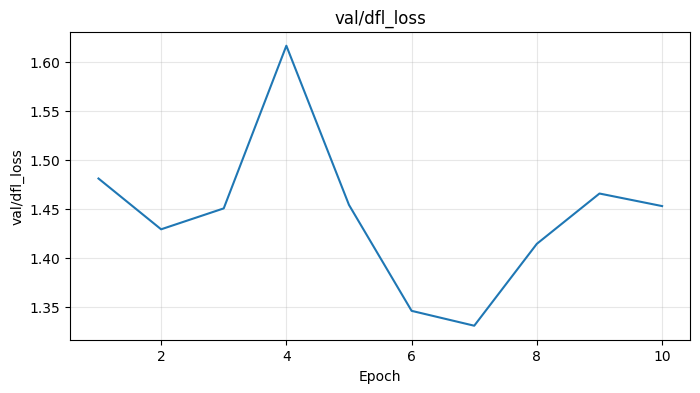

In [29]:
metric_columns = [
    col for col in results_df.columns
    if "loss" in col.lower() or "metrics/" in col.lower()
]

for col in metric_columns:
    plt.figure(figsize=(8, 4))
    plt.plot(results_df["epoch"], results_df[col])
    plt.xlabel("Epoch")
    plt.ylabel(col)
    plt.title(col)
    plt.grid(alpha=0.3)
    plt.show()

In [30]:
best_model = YOLO(str(BEST_WEIGHTS_PATH))

val_metrics = best_model.val(
    data=str(YAML_PATH),
    split="val",
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0
)

print("Métricas en validation:")
print("mAP50:", val_metrics.box.map50)
print("mAP50-95:", val_metrics.box.map)
print("Precision:", val_metrics.box.mp)
print("Recall:", val_metrics.box.mr)


Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 999.2±410.2 MB/s, size: 38.5 KB)
val: Scanning /kaggle/working/visem_tracking_project/yolo_sperm_dataset/labels/val.cache... 4014 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4014/4014 990.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 251/251 8.4it/s 29.8s<0.1s
                   all       4014      44641       0.64      0.712      0.545      0.162
Speed: 0.7ms preprocess, 2.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Métricas en validation:
mAP50: 0.544902128165697
mAP50-95: 0.16190518816939314
Precision: 0.6400412161096755
Recall: 0.7116605446140195


In [31]:
test_metrics = best_model.val(
    data=str(YAML_PATH),
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0
)

print("Métricas en test:")
print("mAP50:", test_metrics.box.map50)
print("mAP50-95:", test_metrics.box.map)
print("Precision:", test_metrics.box.mp)
print("Recall:", test_metrics.box.mr)

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1733.8±677.1 MB/s, size: 82.5 KB)
val: Scanning /kaggle/working/visem_tracking_project/yolo_sperm_dataset/labels/test... 4410 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4410/4410 1.1Kit/s 4.1s0.1s
val: New cache created: /kaggle/working/visem_tracking_project/yolo_sperm_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 276/276 7.5it/s 36.9s<0.1s
                   all       4410     119137      0.517      0.573      0.318     0.0997
Speed: 0.7ms preprocess, 2.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
Métricas en test:
mAP50: 0.3177062034618336
mAP50-95: 0.0996713904360578
Precision: 0.5173555848604732
Recall: 0.5729790073612732


results.png


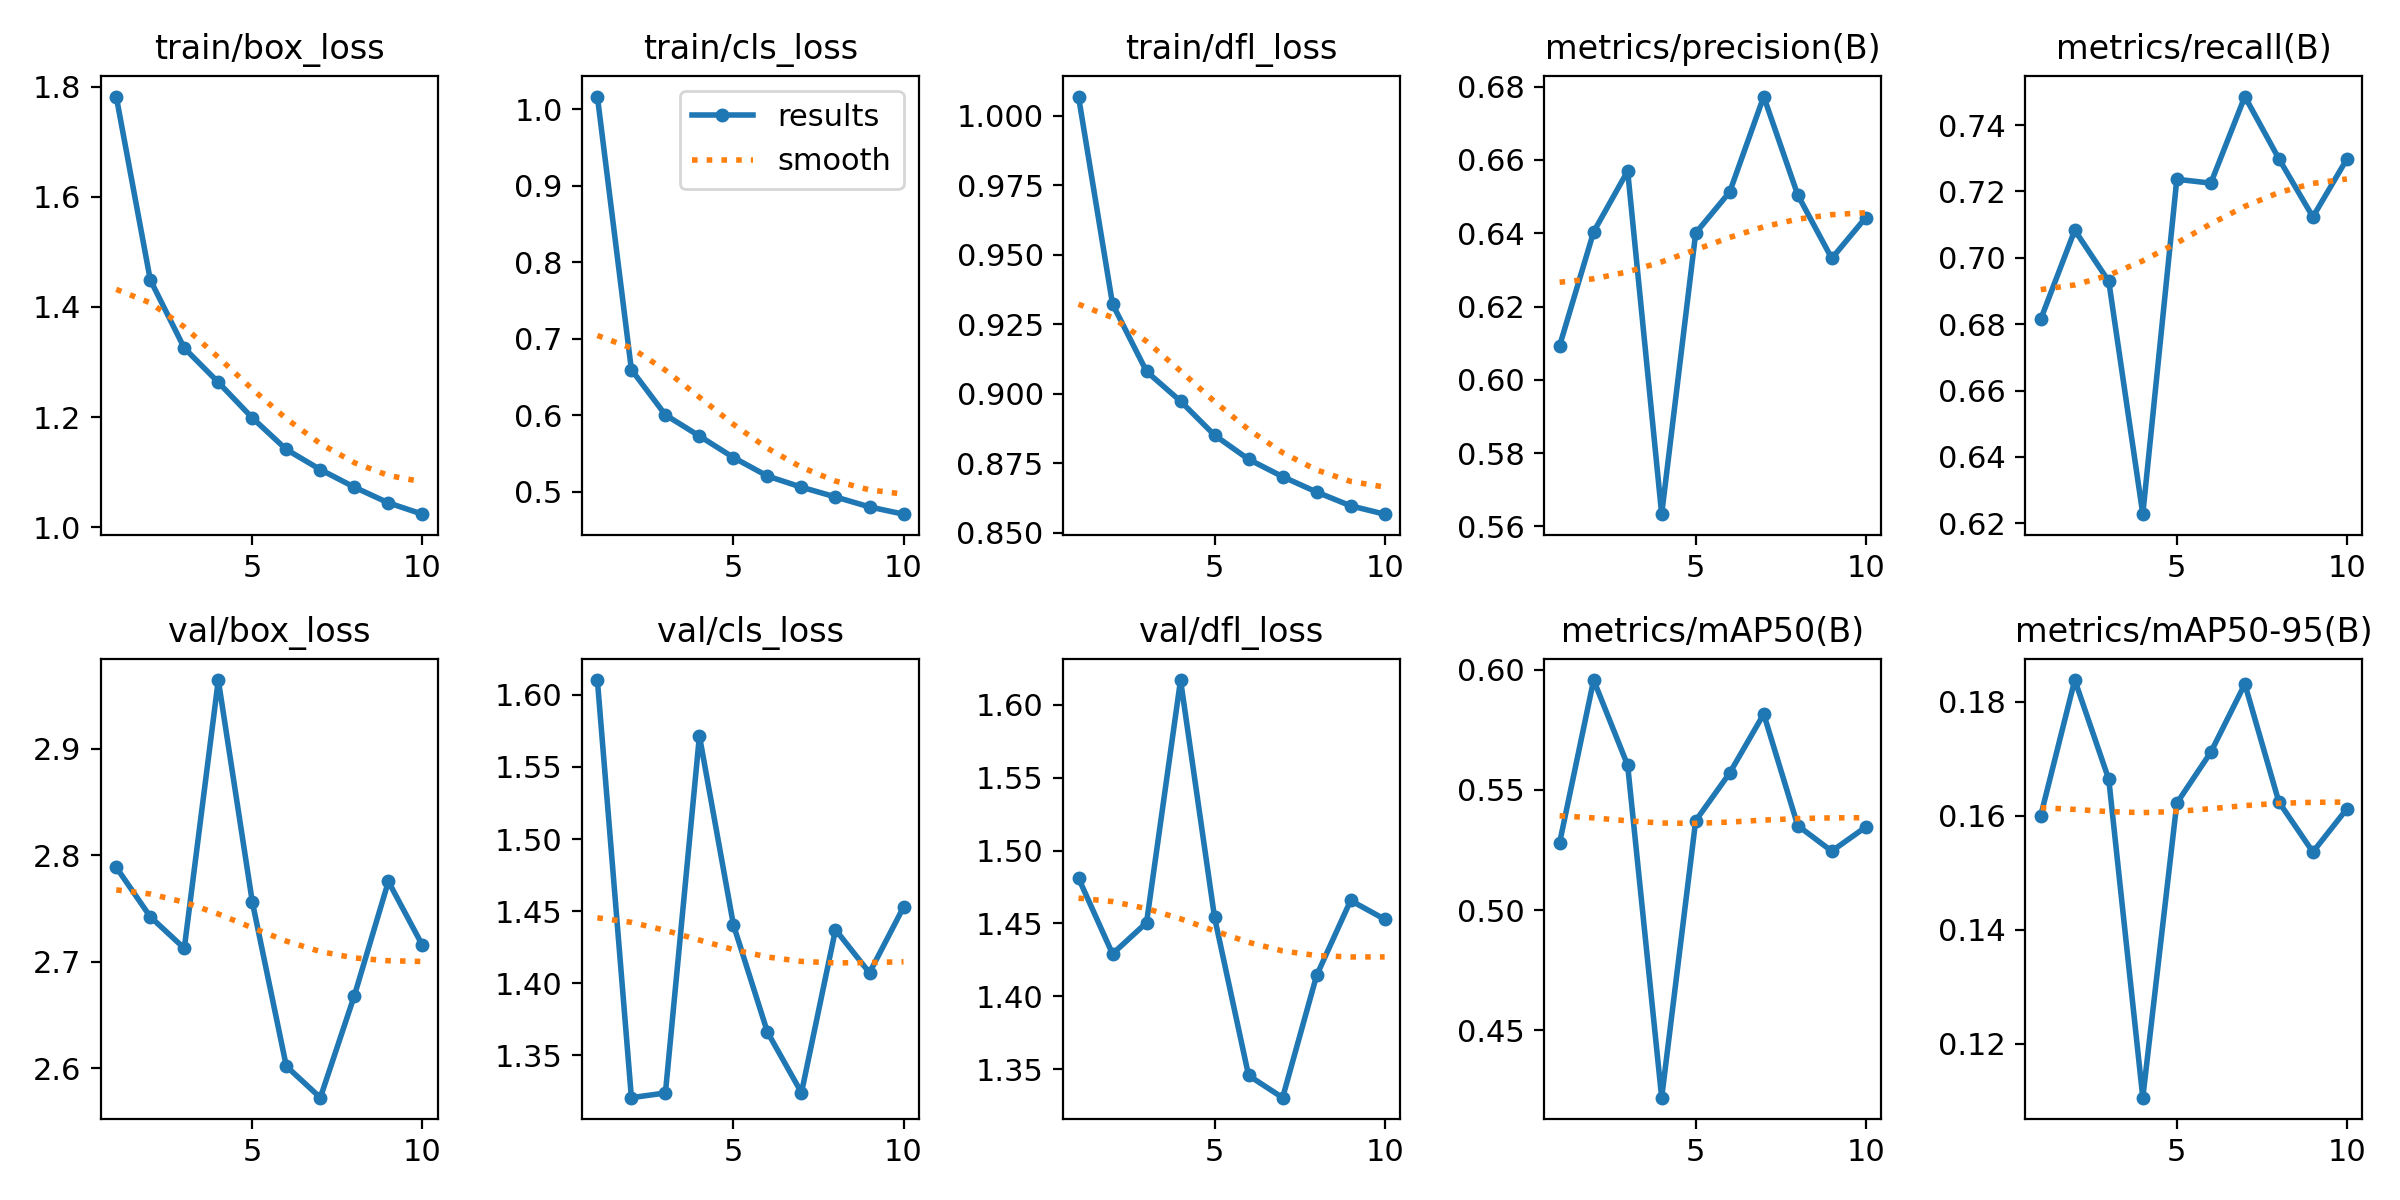

confusion_matrix.png


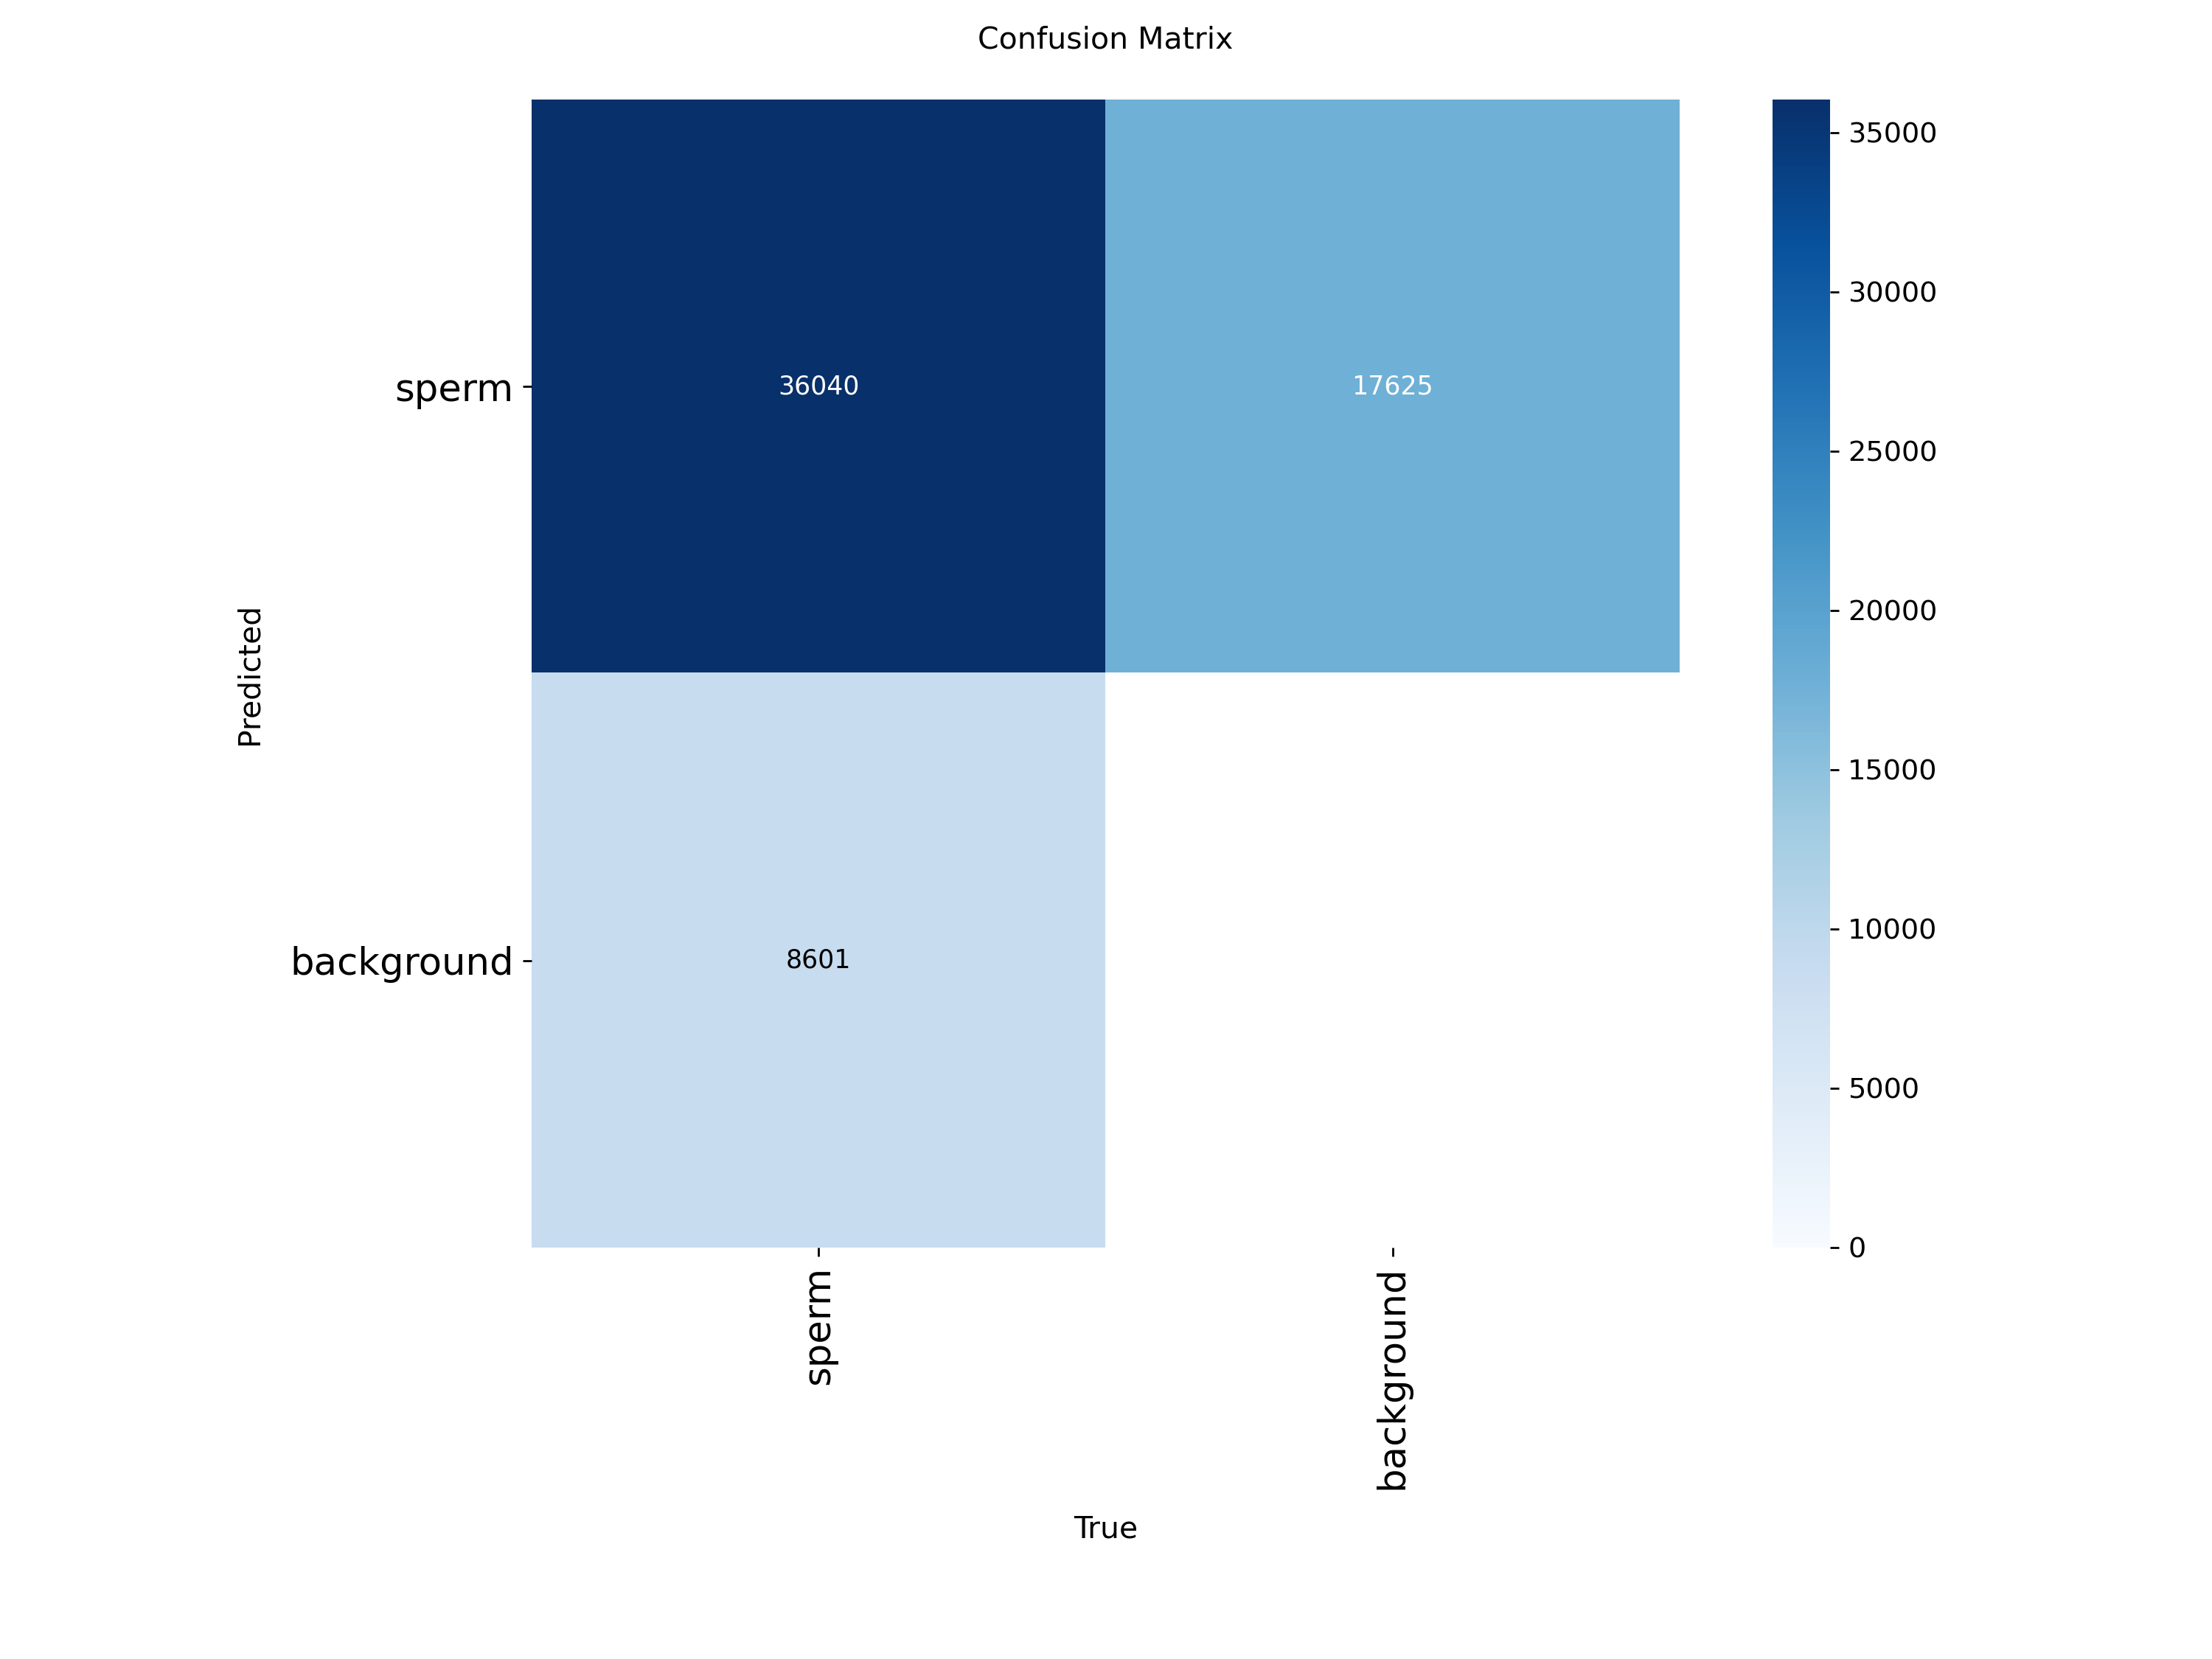

confusion_matrix_normalized.png


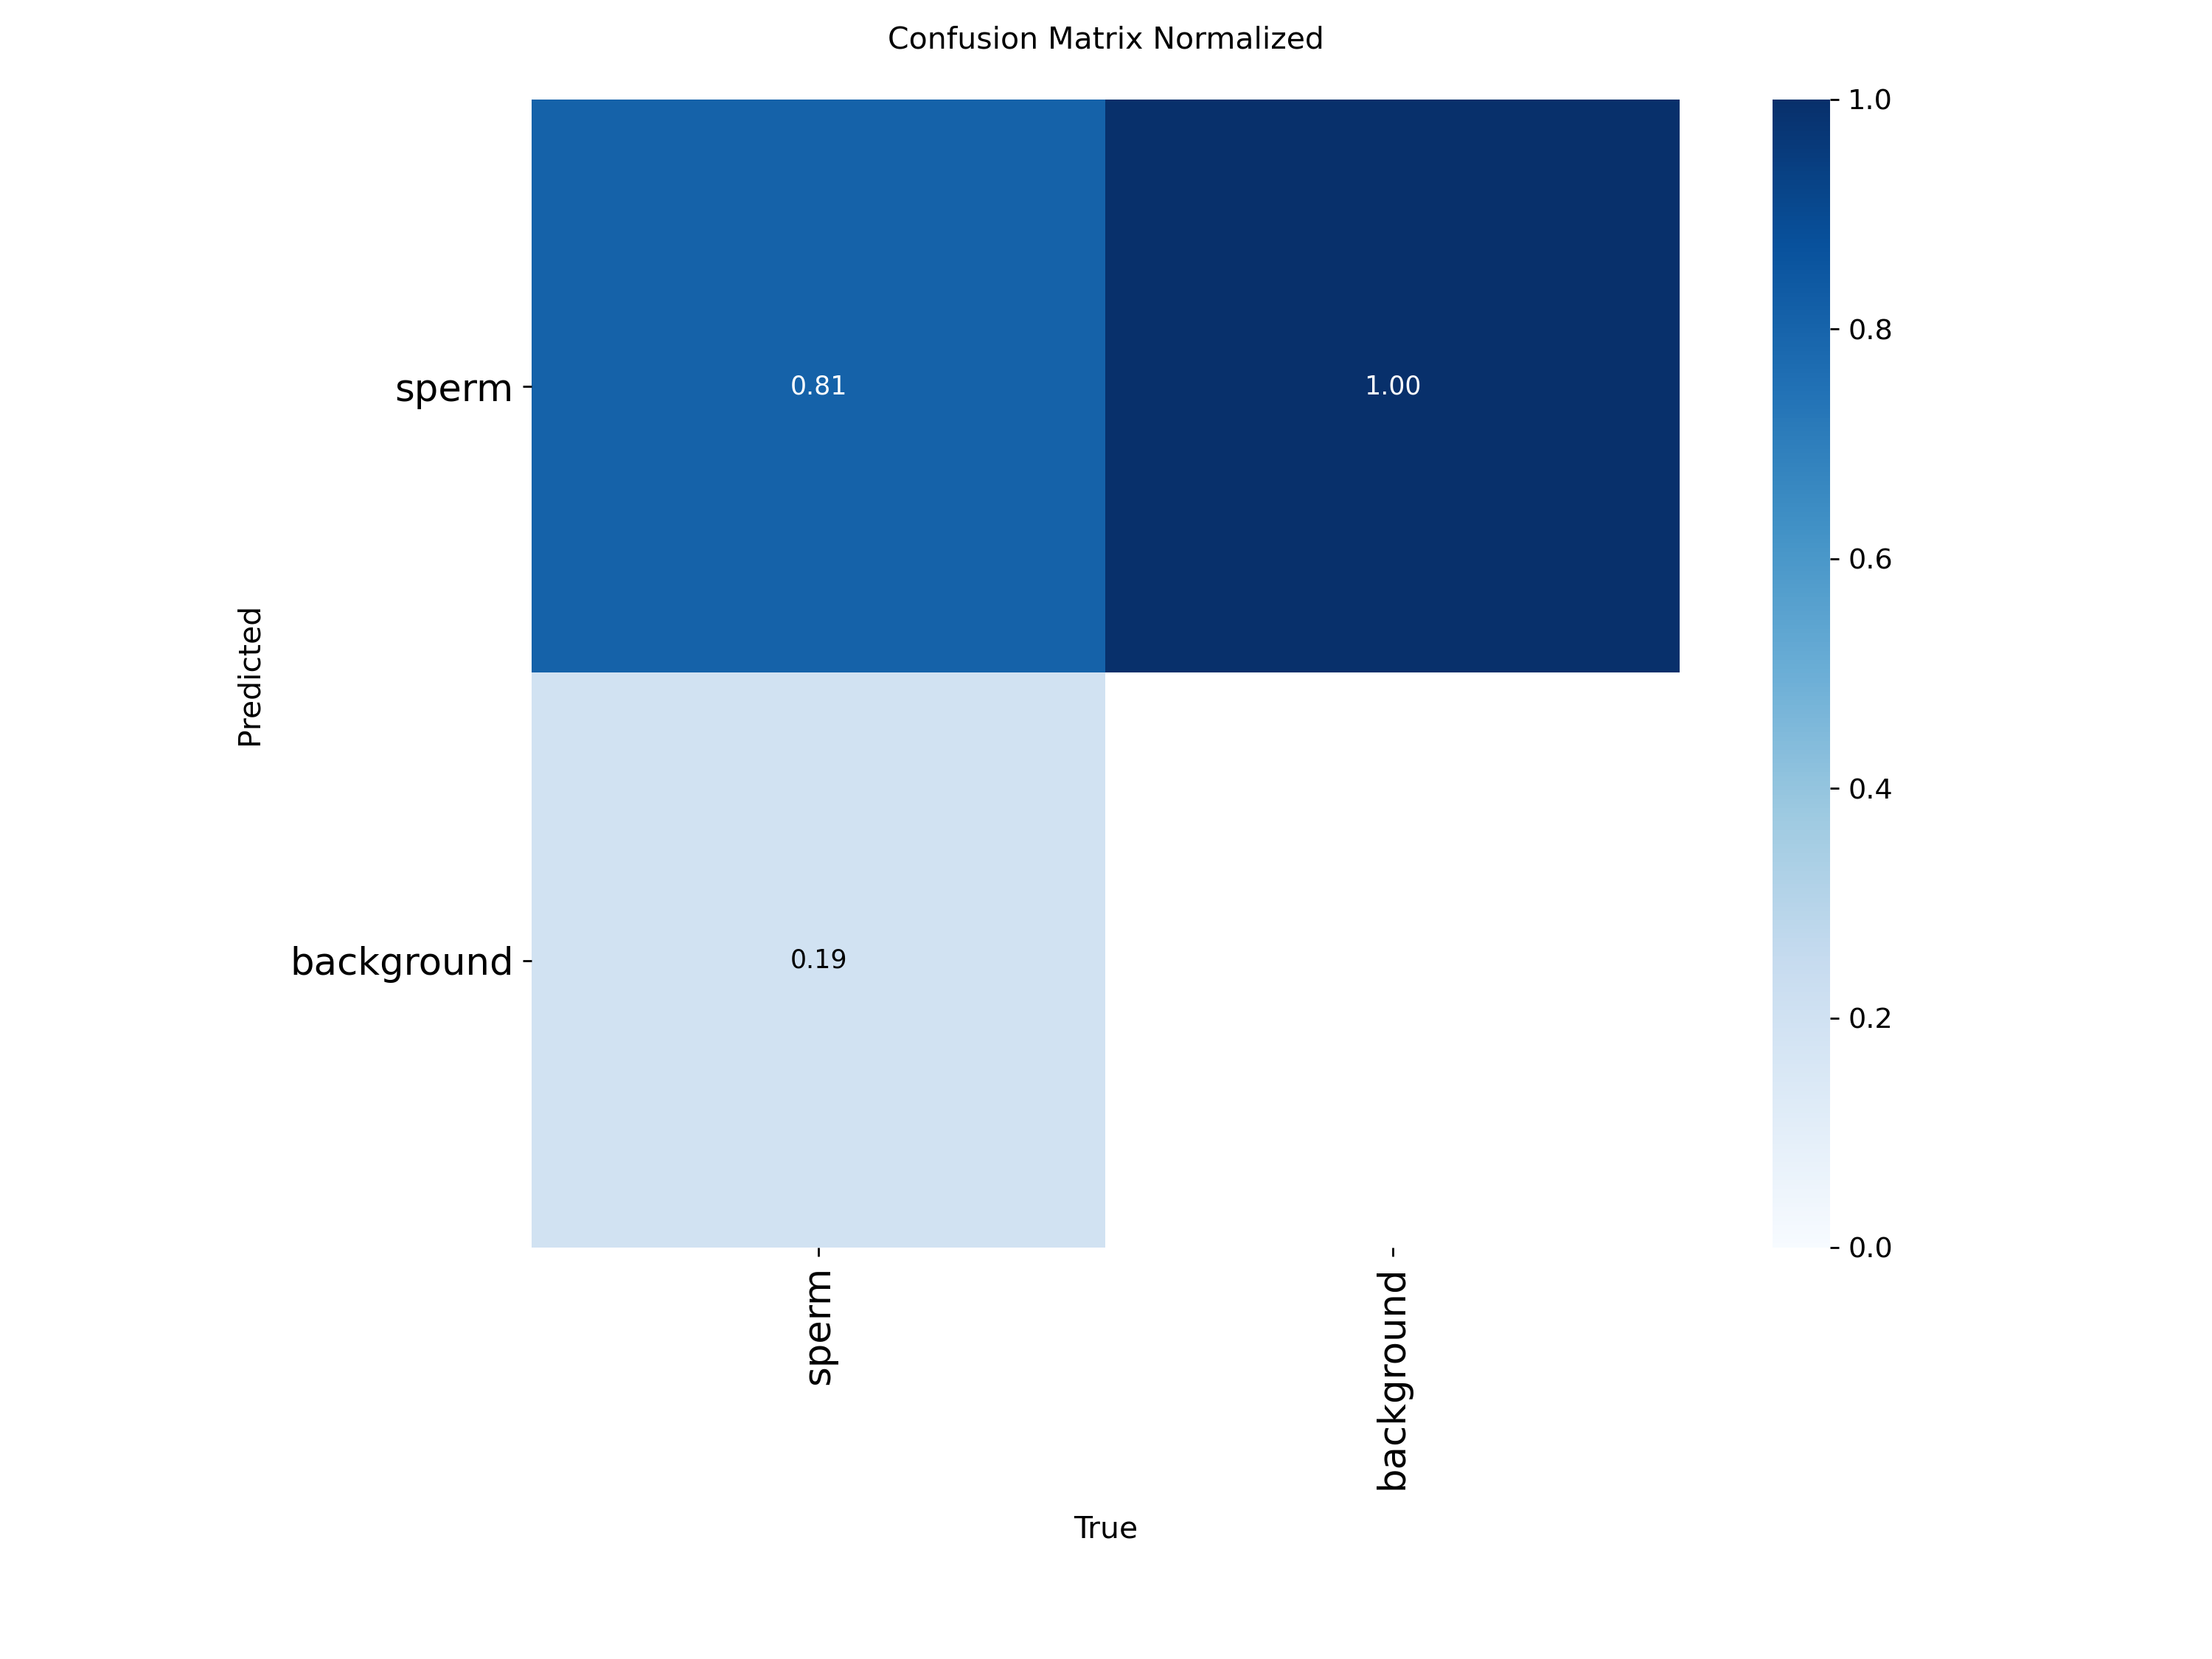

val_batch0_pred.jpg


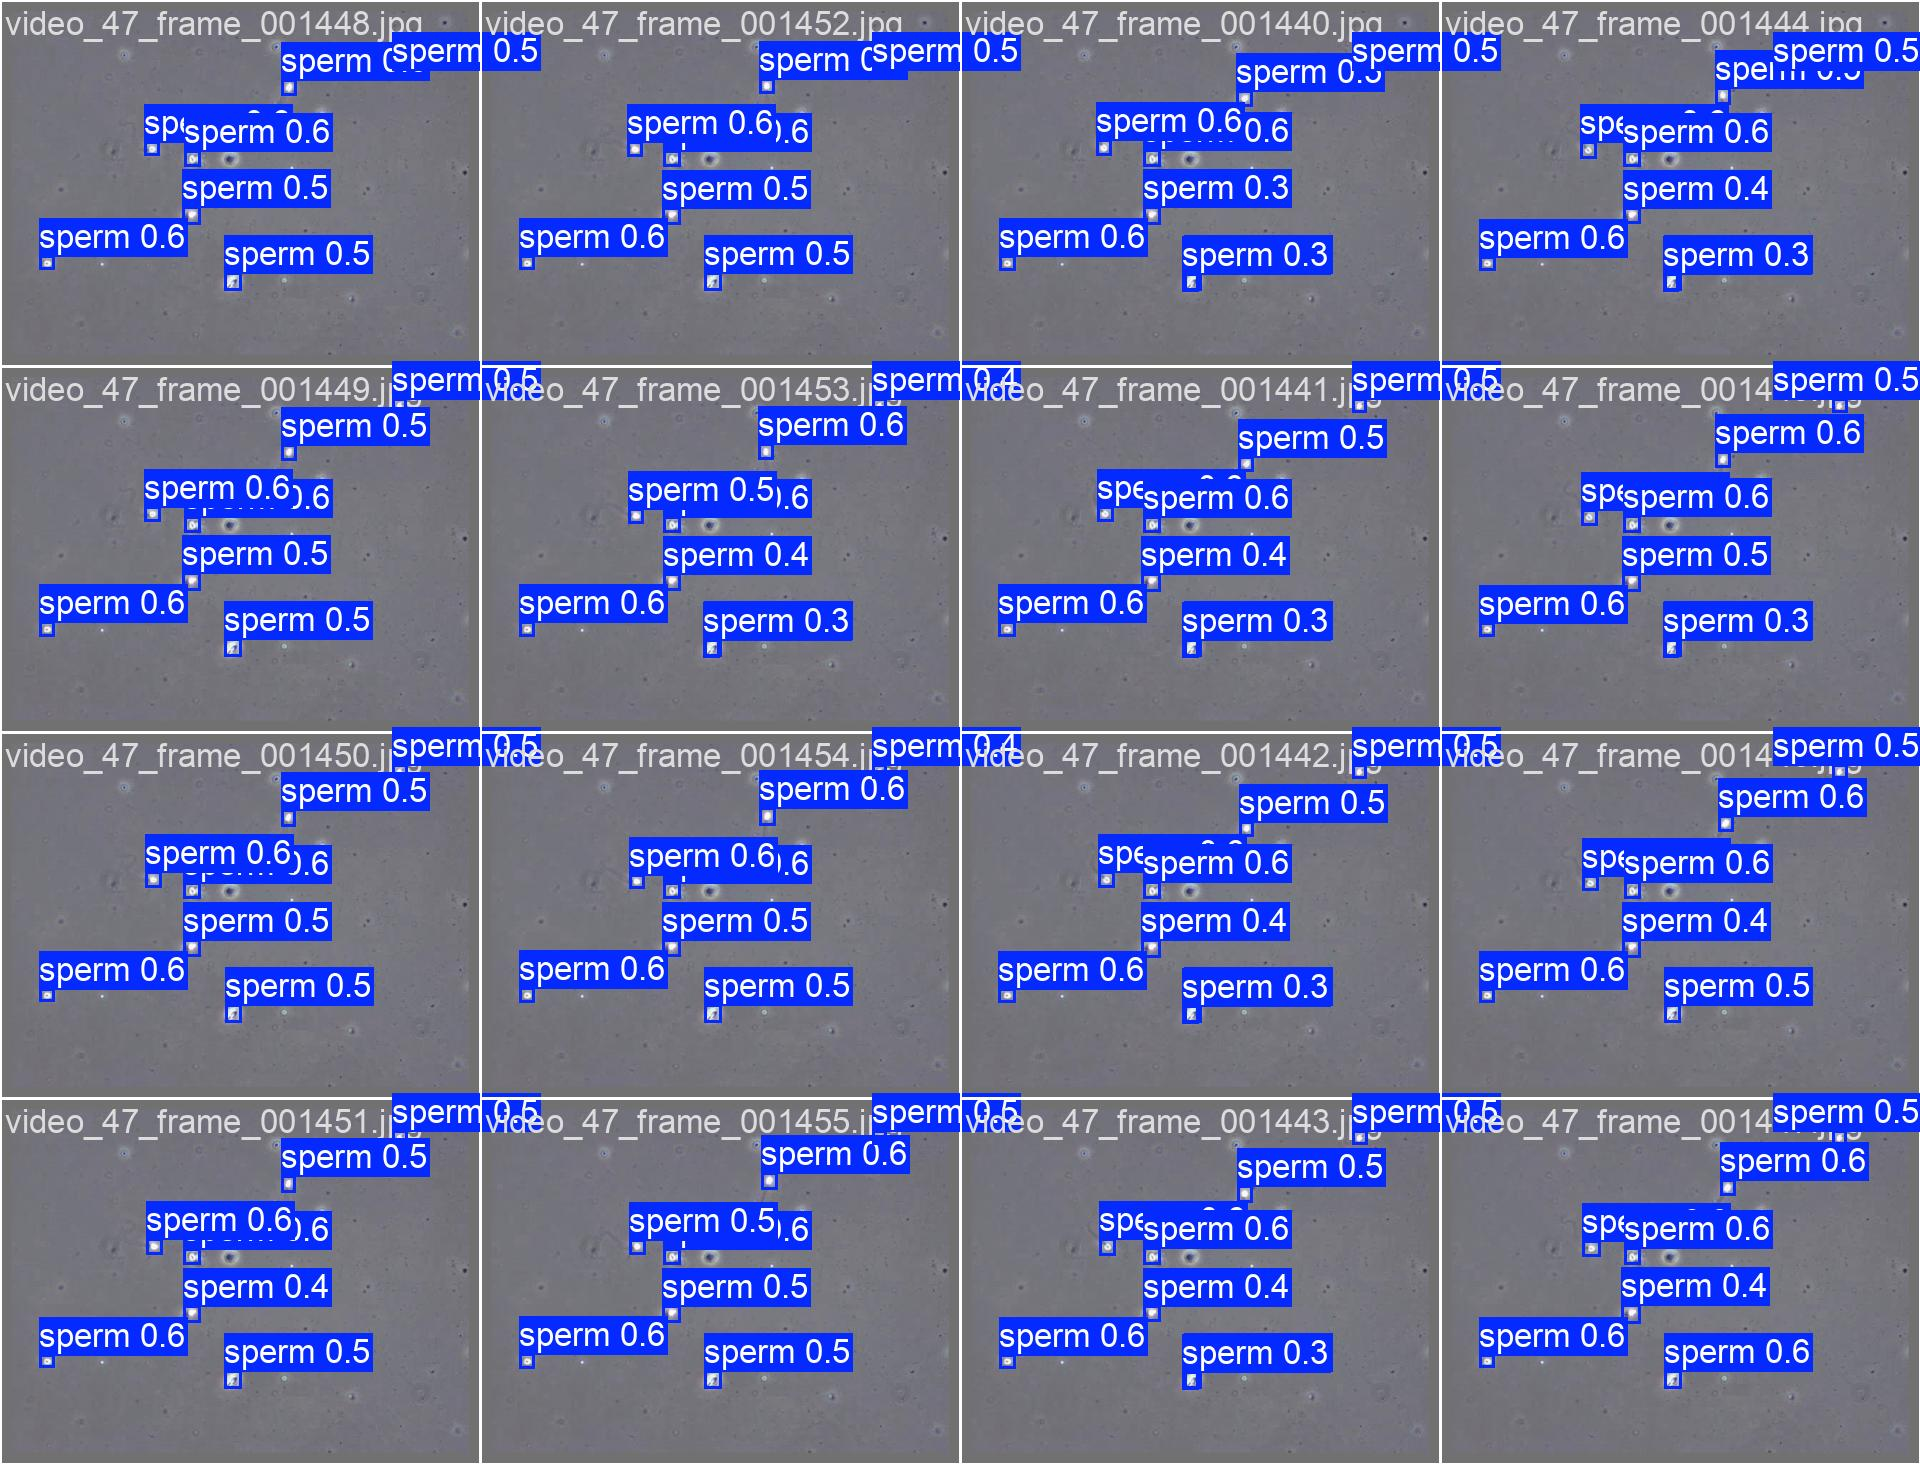

val_batch1_pred.jpg


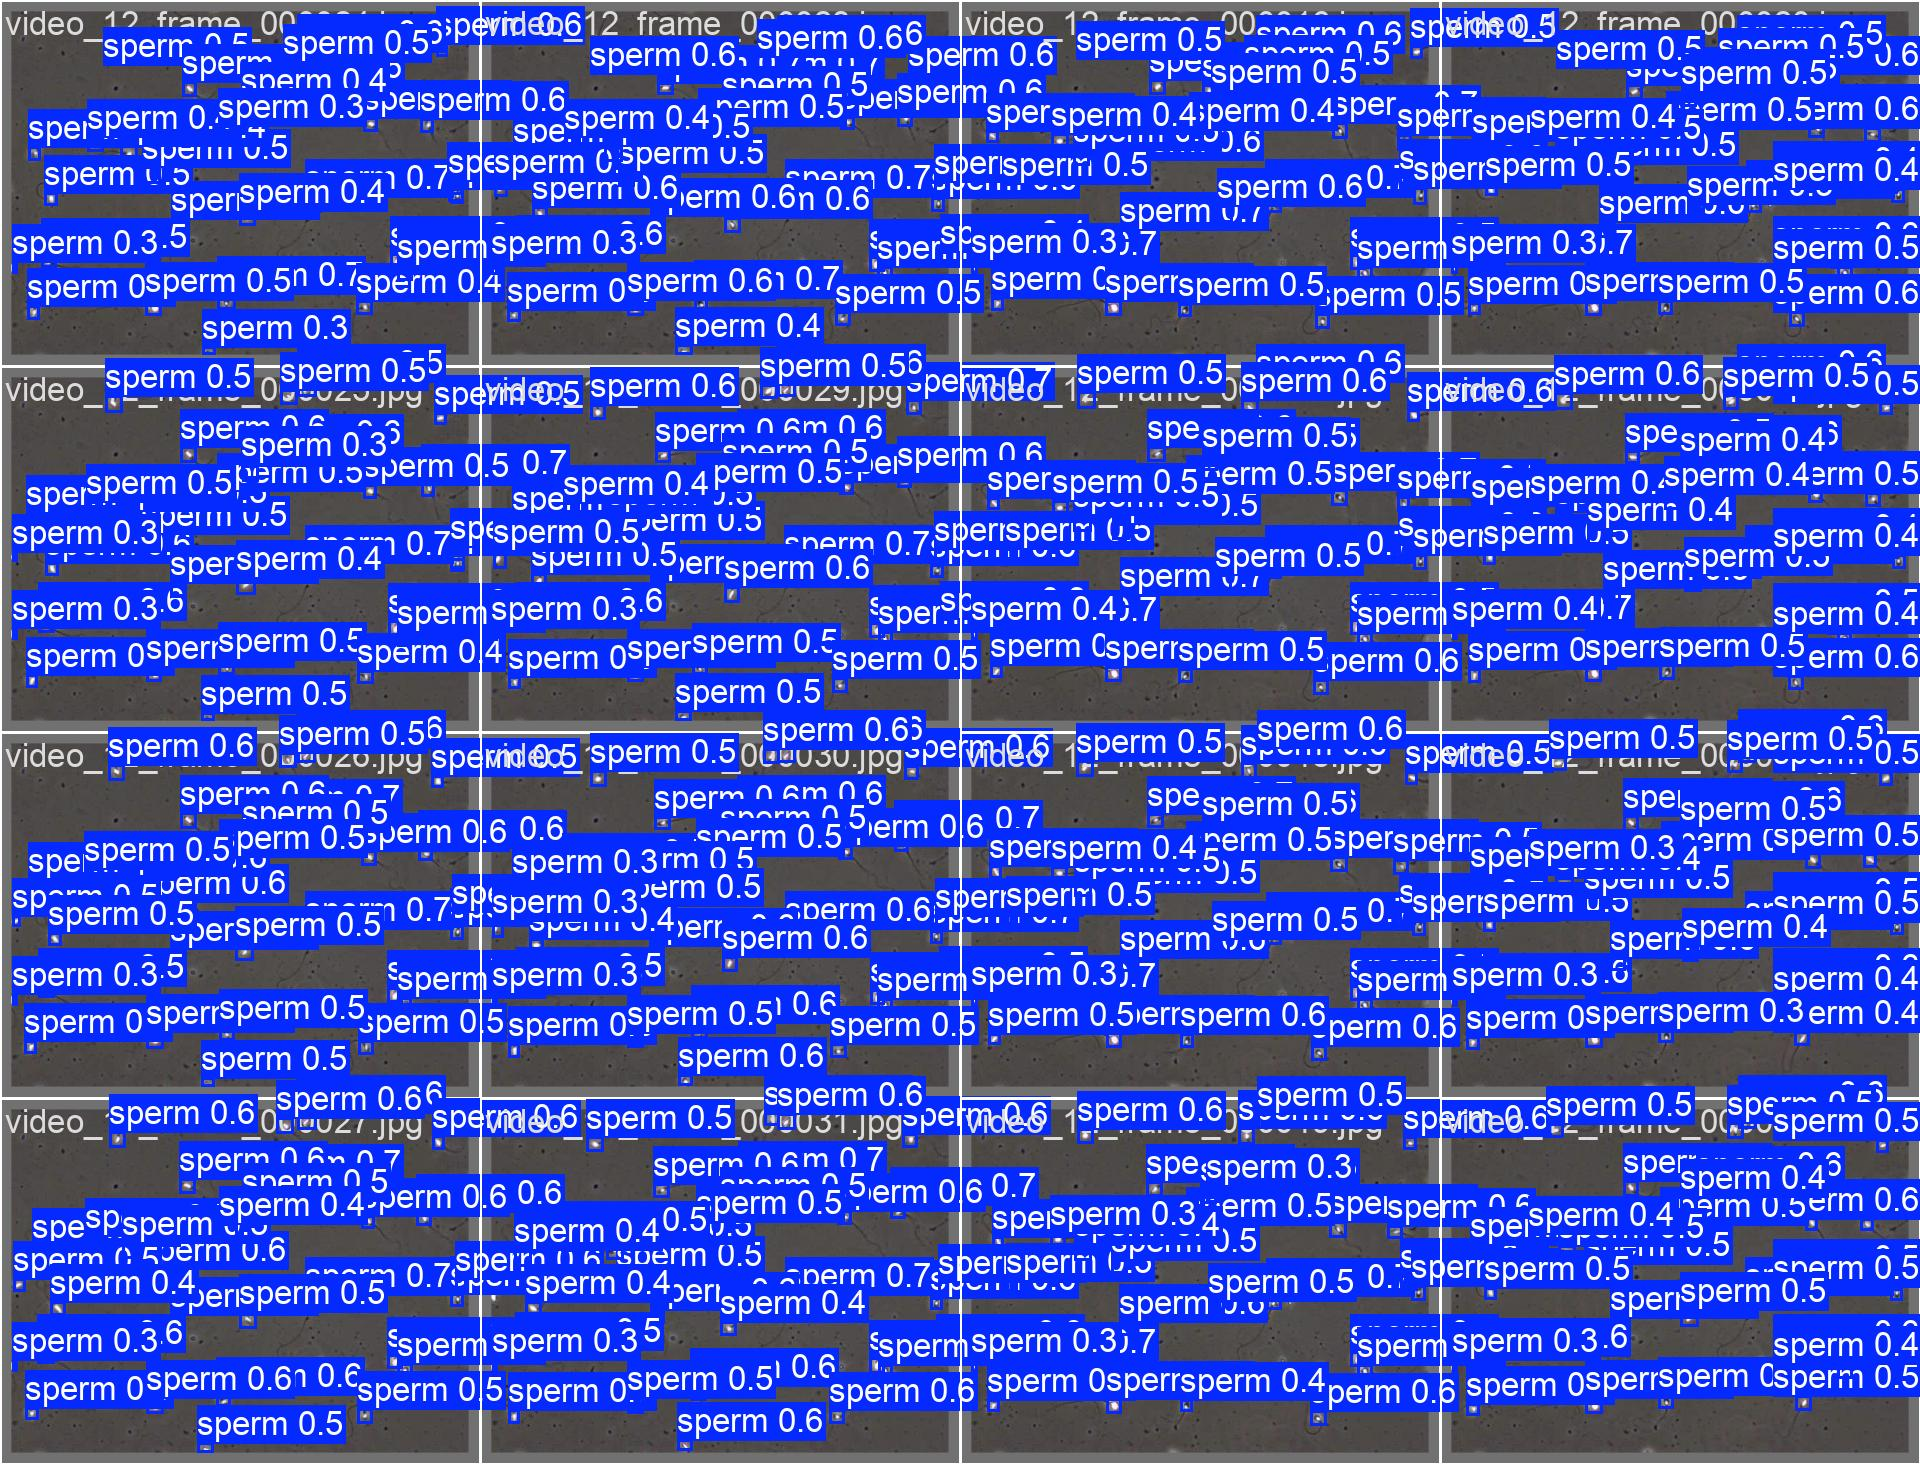

val_batch2_pred.jpg


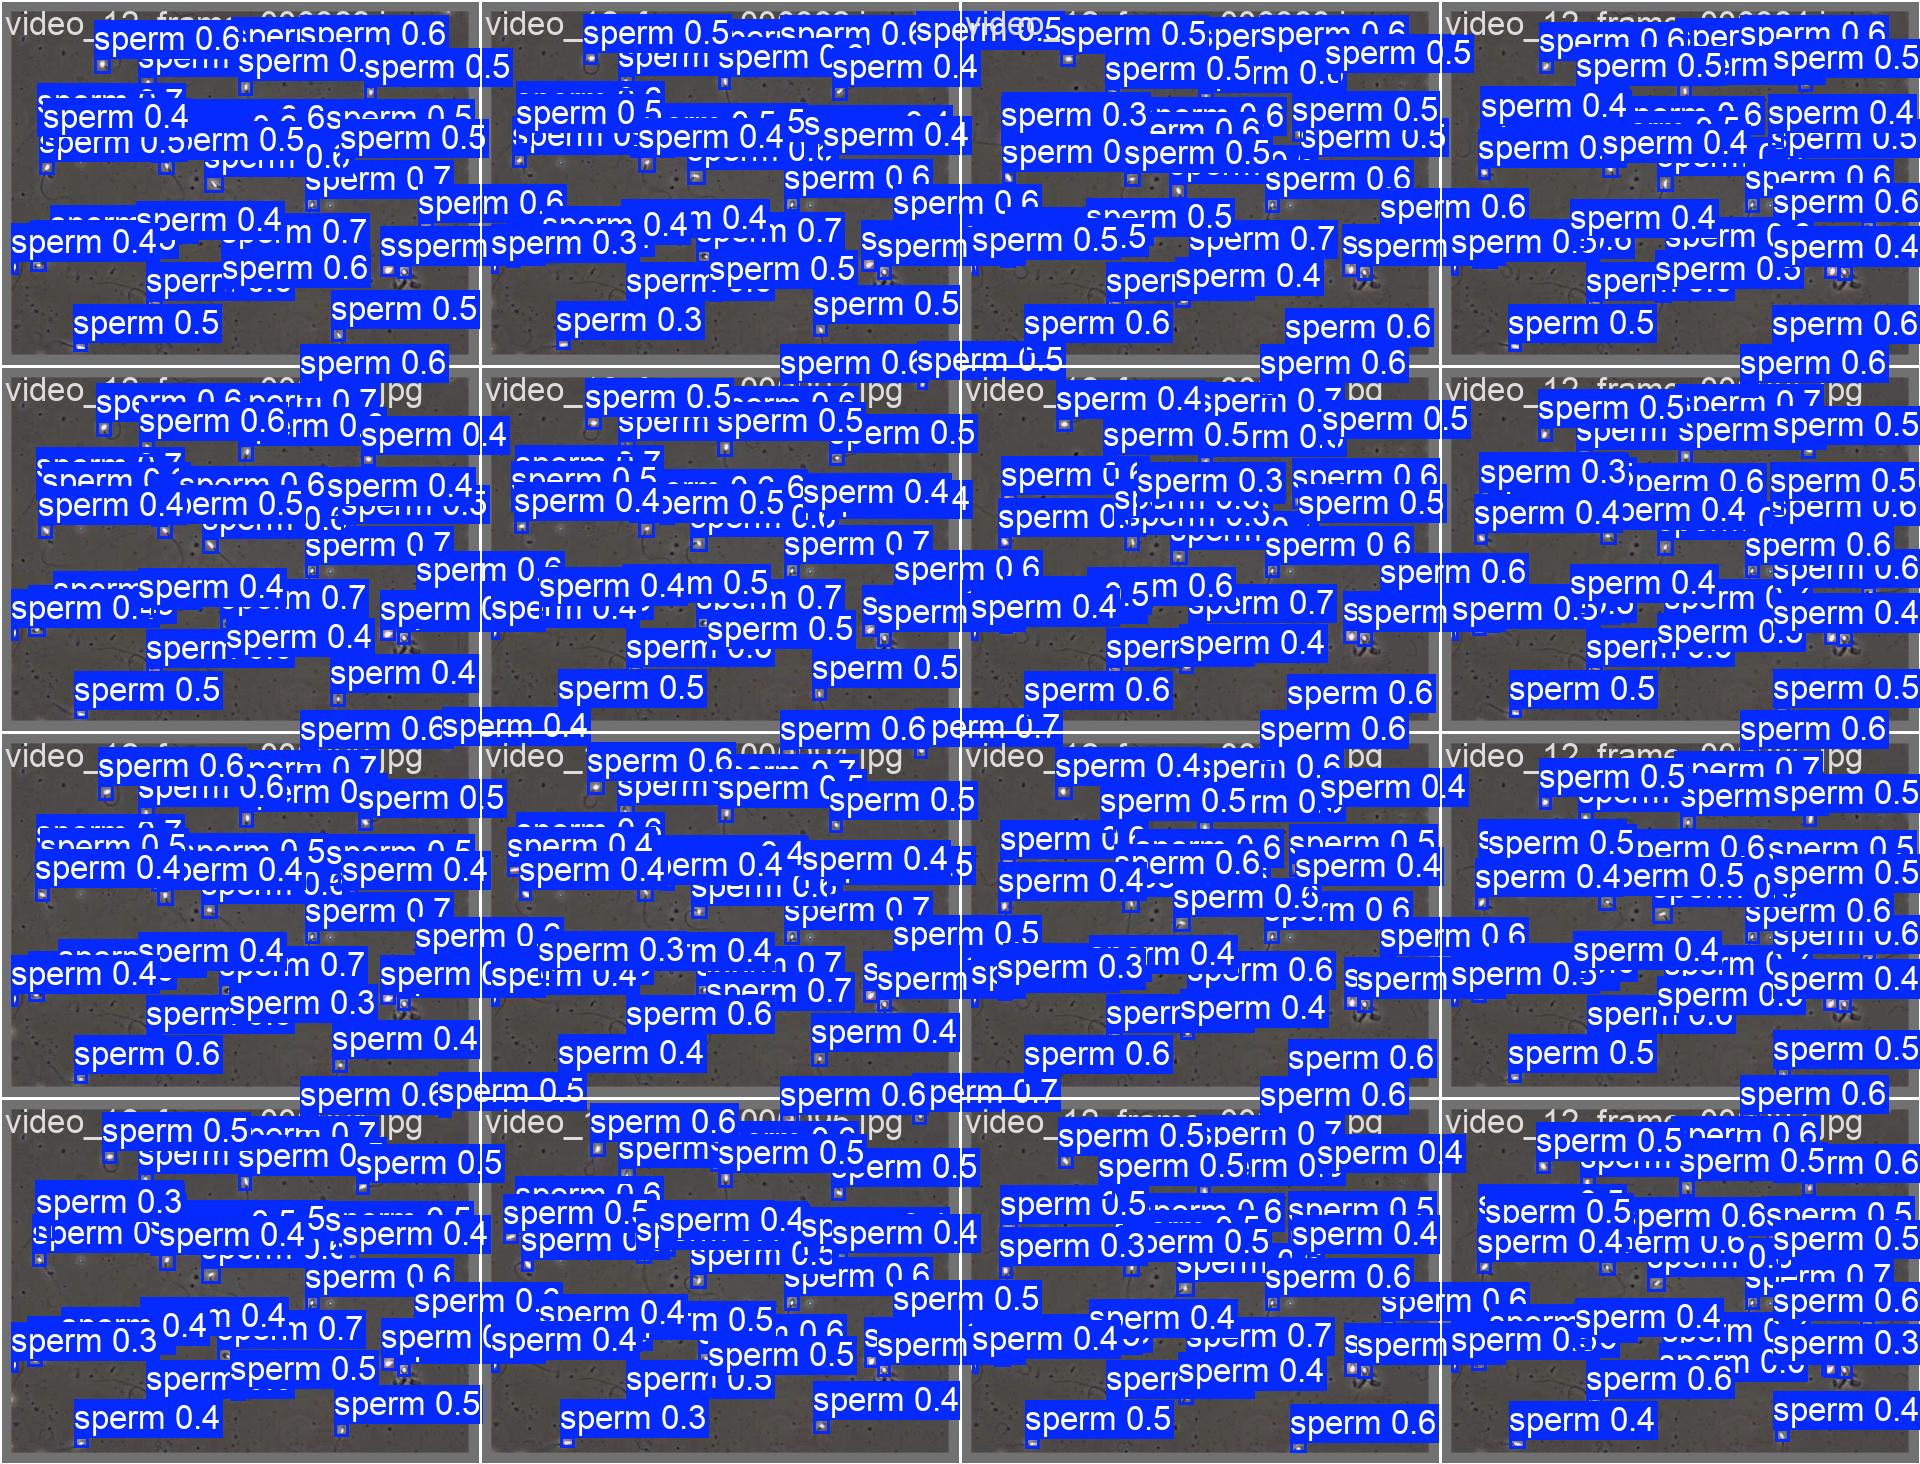

In [32]:
from IPython.display import Image, display

important_plots = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "val_batch0_pred.jpg",
    "val_batch1_pred.jpg",
    "val_batch2_pred.jpg"
]

for plot_name in important_plots:
    plot_path = BEST_RUN_DIR / plot_name
    
    if plot_path.exists():
        print(plot_name)
        display(Image(filename=str(plot_path)))

Imágenes de test encontradas: 4410

0: 480x640 42 sperms, 7.0ms
1: 480x640 24 sperms, 7.0ms
2: 480x640 22 sperms, 7.0ms
3: 480x640 48 sperms, 7.0ms
4: 480x640 23 sperms, 7.0ms
5: 480x640 44 sperms, 7.0ms
Speed: 1.3ms preprocess, 7.0ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


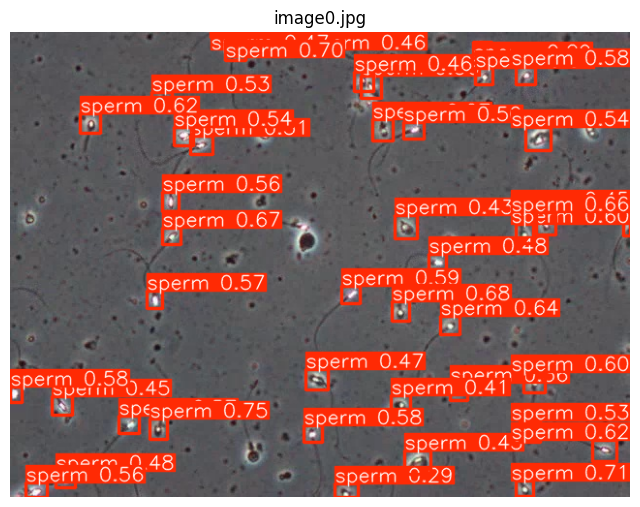

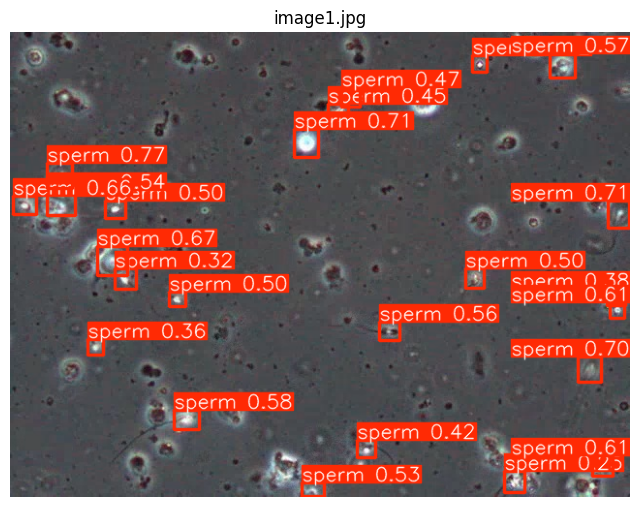

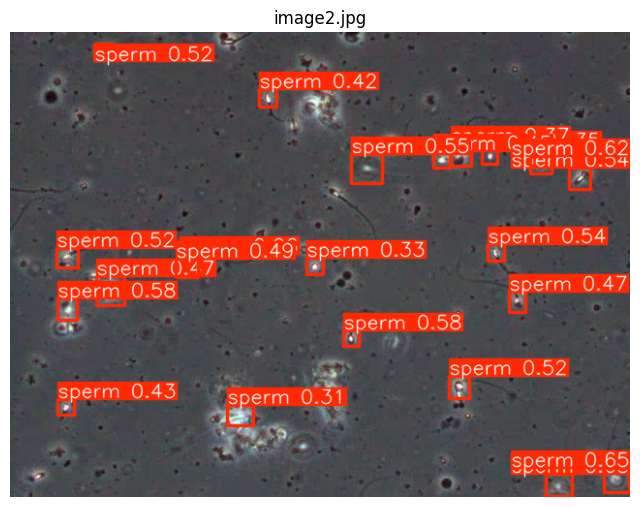

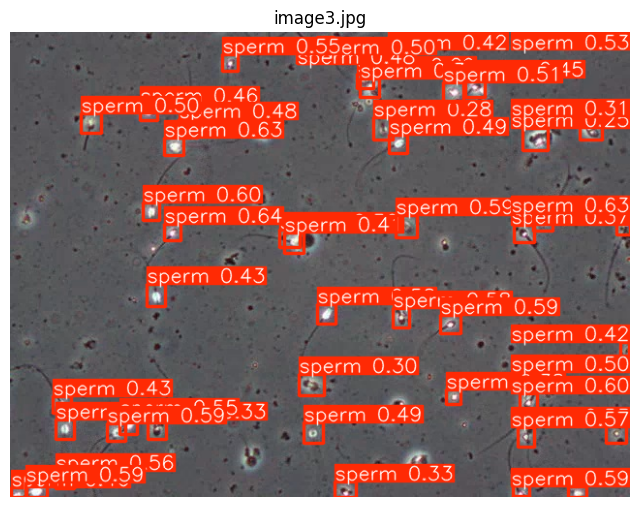

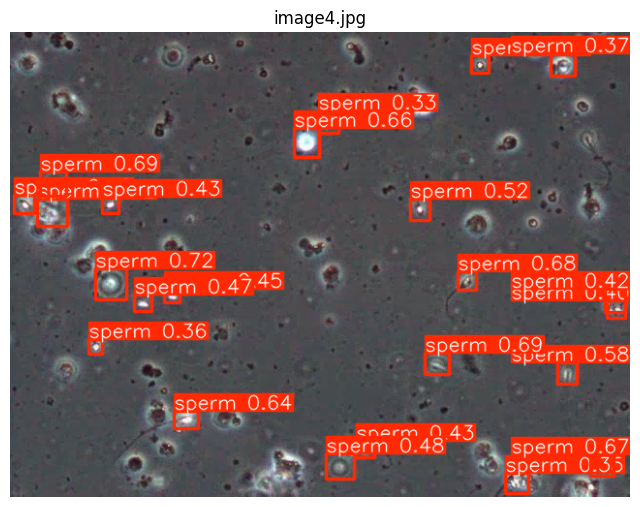

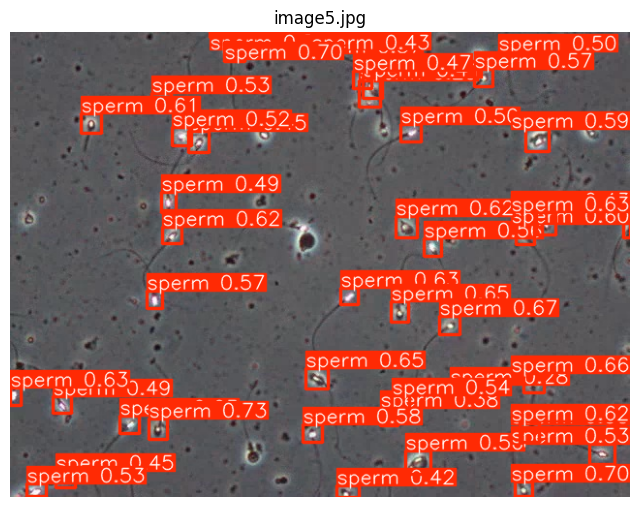

In [33]:
import random

test_images_dir = YOLO_DATASET_DIR / "images" / "test"

test_images = sorted([
    p for p in test_images_dir.glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
])

print("Imágenes de test encontradas:", len(test_images))

sample_images = random.sample(test_images, min(6, len(test_images)))

pred_results = best_model.predict(
    source=[str(p) for p in sample_images],
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0,
    save=False
)

for result in pred_results:
    plotted = result.plot()
    
    plt.figure(figsize=(8, 8))
    plt.imshow(plotted)
    plt.axis("off")
    plt.title(Path(result.path).name)
    plt.show()

In [34]:
detection_counts = []

for result in pred_results:
    n_detections = len(result.boxes)
    
    detection_counts.append({
        "image": Path(result.path).name,
        "detections": n_detections
    })

detections_df = pd.DataFrame(detection_counts)

display(detections_df)

print("Promedio de detecciones por imagen:", detections_df["detections"].mean())
print("Máximo de detecciones en una imagen:", detections_df["detections"].max())
print("Mínimo de detecciones en una imagen:", detections_df["detections"].min())

,image,detections
0,image0.jpg,42
1,image1.jpg,24
2,image2.jpg,22
3,image3.jpg,48
4,image4.jpg,23
5,image5.jpg,44


Promedio de detecciones por imagen: 33.833333333333336
Máximo de detecciones en una imagen: 48
Mínimo de detecciones en una imagen: 22


## Prueba del modelo generado para ver si efectivamente hace tracking correctamente

In [35]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import random

# Buscar último entrenamiento si BEST_WEIGHTS_PATH no existe todavía
if "BEST_WEIGHTS_PATH" not in globals():
    RUNS_DIR = PROJECT_DIR / "runs"

    train_dirs = sorted(
        [p for p in RUNS_DIR.glob("*") if (p / "weights" / "best.pt").exists()],
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    if len(train_dirs) == 0:
        raise FileNotFoundError("No se encontró ningún best.pt. Entrena YOLO primero.")

    BEST_RUN_DIR = train_dirs[0]
    BEST_WEIGHTS_PATH = BEST_RUN_DIR / "weights" / "best.pt"

print("Usando modelo:")
print(BEST_WEIGHTS_PATH)

# Carpeta de resultados de tracking
TRACKING_OUT_DIR = PROJECT_DIR / "tracking_results"
TRACKING_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Funciones para leer video_id y frame desde el nombre de imagen generado antes
def parse_video_id_from_image_name(path):
    name = Path(path).stem
    match = re.search(r"video_([^_]+)_frame_", name)
    return match.group(1) if match else None

def parse_frame_number_from_image_name(path):
    name = Path(path).stem
    match = re.search(r"frame_(\d+)", name)
    return int(match.group(1)) if match else None

# Tomamos imágenes del split test
test_images_dir = YOLO_DATASET_DIR / "images" / "test"

test_images = sorted([
    p for p in test_images_dir.glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
])

if len(test_images) == 0:
    raise FileNotFoundError("No hay imágenes en images/test. Revisa que el dataset YOLO se haya creado bien.")

# Crear tabla de imágenes test
test_frames_df = pd.DataFrame({
    "image_path": test_images
})

test_frames_df["video"] = test_frames_df["image_path"].apply(parse_video_id_from_image_name)
test_frames_df["frame"] = test_frames_df["image_path"].apply(parse_frame_number_from_image_name)

test_frames_df = test_frames_df.dropna().copy()
test_frames_df["video"] = test_frames_df["video"].astype(str)
test_frames_df["frame"] = test_frames_df["frame"].astype(int)

# Elegimos automáticamente un video de test con bastantes frames
video_counts = (
    test_frames_df
    .groupby("video")
    .size()
    .sort_values(ascending=False)
)

print("Videos disponibles en test:")
display(video_counts)

TEST_VIDEO_ID = video_counts.index[0]

print("Video seleccionado para tracking:", TEST_VIDEO_ID)

selected_video_frames = (
    test_frames_df[test_frames_df["video"] == TEST_VIDEO_ID]
    .sort_values("frame")
    .reset_index(drop=True)
)

print("Frames disponibles para el video seleccionado:", len(selected_video_frames))
display(selected_video_frames.head())

# Cargar modelo
tracking_model = YOLO(str(BEST_WEIGHTS_PATH))

Usando modelo:
/kaggle/working/visem_tracking_project/runs/sperm_yolov8n_detector/weights/best.pt
Videos disponibles en test:


video
11    1470
19    1470
54    1470
dtype: int64

Video seleccionado para tracking: 11
Frames disponibles para el video seleccionado: 1470


,image_path,video,frame
0,/kaggle/working/visem_tracking_project/yolo_sperm_dataset/images/test/video_11_frame_000000.jpg,11,0
1,/kaggle/working/visem_tracking_project/yolo_sperm_dataset/images/test/video_11_frame_000001.jpg,11,1
2,/kaggle/working/visem_tracking_project/yolo_sperm_dataset/images/test/video_11_frame_000002.jpg,11,2
3,/kaggle/working/visem_tracking_project/yolo_sperm_dataset/images/test/video_11_frame_000003.jpg,11,3
4,/kaggle/working/visem_tracking_project/yolo_sperm_dataset/images/test/video_11_frame_000004.jpg,11,4


In [36]:
# Parámetros de tracking
CONF_THRES = 0.25
IOU_THRES = 0.5
IMG_SIZE = 640

pred_rows = []

# Reiniciamos el modelo para evitar mezclar estado de trackers anteriores
tracking_model = YOLO(str(BEST_WEIGHTS_PATH))

for _, row in selected_video_frames.iterrows():
    image_path = row["image_path"]
    frame_number = int(row["frame"])
    
    results = tracking_model.track(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=CONF_THRES,
        iou=IOU_THRES,
        tracker="bytetrack.yaml",
        persist=True,
        verbose=False,
        device=0
    )
    
    result = results[0]
    
    if result.boxes is None or len(result.boxes) == 0:
        continue
    
    boxes = result.boxes
    
    xywhn = boxes.xywhn.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    
    if boxes.id is None:
        track_ids = [-1] * len(xywhn)
    else:
        track_ids = boxes.id.cpu().numpy().astype(int)
    
    for box, conf, track_id in zip(xywhn, confs, track_ids):
        x_center, y_center, width, height = box
        
        # Ignorar detecciones sin ID de tracking
        if track_id == -1:
            continue
        
        pred_rows.append({
            "video": str(TEST_VIDEO_ID),
            "frame": frame_number,
            "track_id": str(track_id),
            "x_center": float(x_center),
            "y_center": float(y_center),
            "width": float(width),
            "height": float(height),
            "confidence": float(conf)
        })

pred_tracks_df = pd.DataFrame(pred_rows)

if len(pred_tracks_df) == 0:
    raise ValueError("El tracker no generó trayectorias. Prueba bajando CONF_THRES a 0.15.")

pred_tracks_df["track_uid"] = (
    pred_tracks_df["video"].astype(str) + "__pred_" + pred_tracks_df["track_id"].astype(str)
)

pred_tracks_df = pred_tracks_df.sort_values(
    ["video", "track_id", "frame"]
).reset_index(drop=True)

pred_tracks_path = TRACKING_OUT_DIR / f"predicted_tracks_video_{TEST_VIDEO_ID}.csv"
pred_tracks_df.to_csv(pred_tracks_path, index=False)

print("Trayectorias predichas guardadas en:")
print(pred_tracks_path)

print("Puntos predichos:", len(pred_tracks_df))
print("Tracks predichos:", pred_tracks_df["track_uid"].nunique())

display(pred_tracks_df.head())

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 258ms
Prepared 1 package in 87ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Trayectorias predichas guardadas en:
/kaggle/working/visem_tracking_project/tracking_results/predicted_tracks_video_11.csv
Puntos predichos: 66841
Tracks predichos: 276


,video,frame,track_id,x_center,y_center,width,height,confidence,track_uid
0,11,0,1,0.771088,0.062517,0.025801,0.036102,0.719670,11__pred_1
1,11,1,1,0.771230,0.062360,0.025663,0.035907,0.719215,11__pred_1
2,11,2,1,0.771160,0.062202,0.025929,0.036278,0.699285,11__pred_1
3,11,3,1,0.771128,0.061992,0.025581,0.035786,0.688765,11__pred_1
4,11,4,1,0.771032,0.062264,0.025992,0.036357,0.649520,11__pred_1


In [38]:
# ============================================================
# Celda puente: adaptar las trayectorias reales al formato usado
# por las celdas de comparación YOLO + Tracking
# ============================================================

from pathlib import Path
import pandas as pd

# Si trajectory_df existe en memoria, usamos esa.
# Si no existe, la cargamos desde el CSV guardado en el Paso 2.
if "trajectory_df" in globals():
    print("Usando trajectory_df existente en memoria.")
    gt_source_df = trajectory_df.copy()

elif "TABLES_DIR" in globals() and (TABLES_DIR / "sperm_trajectory_points.csv").exists():
    print("Cargando trayectorias desde sperm_trajectory_points.csv.")
    gt_source_df = pd.read_csv(TABLES_DIR / "sperm_trajectory_points.csv")

elif "TABLES_DIR" in globals() and (TABLES_DIR / "usable_sperm_trajectory_points.csv").exists():
    print("Cargando trayectorias desde usable_sperm_trajectory_points.csv.")
    gt_source_df = pd.read_csv(TABLES_DIR / "usable_sperm_trajectory_points.csv")

else:
    raise NameError(
        "No existe trajectory_df ni se encontraron CSVs de trayectorias. "
        "Ejecuta primero el Paso 2 de trayectorias reales."
    )

# Crear trajectories_df con los nombres que esperan las celdas de tracking
trajectories_df = gt_source_df.copy()

# Renombrar columnas si vienen con los nombres del notebook actual
rename_map = {}

if "video_id" in trajectories_df.columns:
    rename_map["video_id"] = "video"

if "frame_number" in trajectories_df.columns:
    rename_map["frame_number"] = "frame"

trajectories_df = trajectories_df.rename(columns=rename_map)

# Asegurar tipos
trajectories_df["video"] = trajectories_df["video"].astype(str)
trajectories_df["frame"] = trajectories_df["frame"].astype(int)
trajectories_df["track_id"] = trajectories_df["track_id"].astype(str)

# Asegurar track_uid
if "track_uid" not in trajectories_df.columns:
    trajectories_df["track_uid"] = (
        trajectories_df["video"].astype(str) + "__gt_" + trajectories_df["track_id"].astype(str)
    )

print("trajectories_df creado correctamente.")
print("Puntos ground truth:", len(trajectories_df))
print("Videos:", trajectories_df["video"].nunique())
print("Tracks:", trajectories_df["track_uid"].nunique())

display(trajectories_df.head())

Usando trajectory_df existente en memoria.
trajectories_df creado correctamente.
Puntos ground truth: 612377
Videos: 20
Tracks: 1121


,video,track_id,track_uid,frame,x_center,y_center,width,height,area_norm,txt_path
0,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,0,0.275781,0.412500,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...
1,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,1,0.275767,0.412549,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1_w...
2,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,2,0.275754,0.412598,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_2_w...
3,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,3,0.275740,0.412647,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_3_w...
4,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,4,0.275726,0.412697,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_4_w...


Ground truth:
Puntos: 53854
Tracks: 55

Predicción:
Puntos: 66841
Tracks: 276


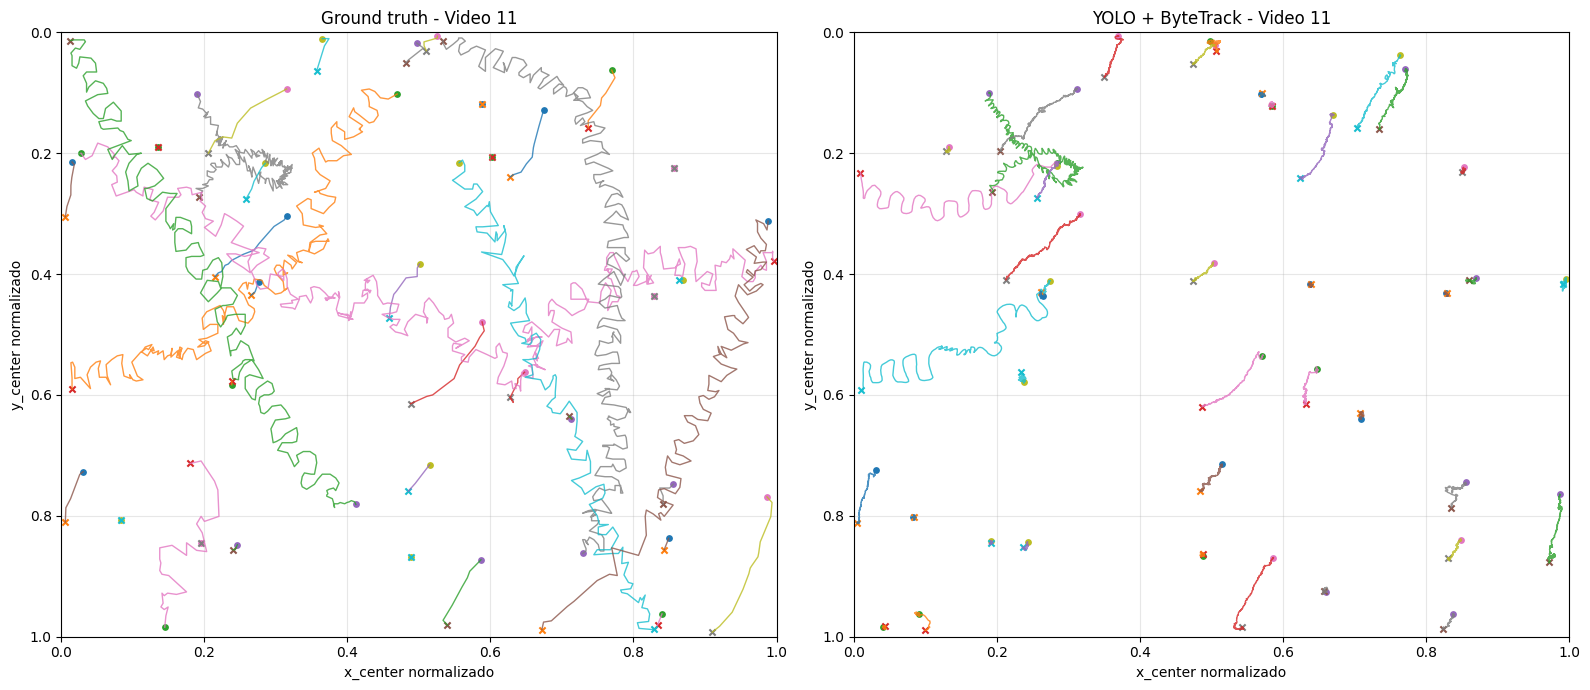

Comparación guardada en:
/kaggle/working/visem_tracking_project/tracking_results/gt_vs_pred_tracks_video_11.png


In [39]:
def plot_tracks(ax, df, title, max_tracks=40, min_frames=5):
    if df.empty:
        ax.set_title(title + " vacío")
        return
    
    summary = (
        df.groupby("track_uid")
        .agg(
            n_frames=("frame", "nunique"),
            first_frame=("frame", "min"),
            last_frame=("frame", "max")
        )
        .reset_index()
    )
    
    selected_tracks = (
        summary[summary["n_frames"] >= min_frames]
        .sort_values("n_frames", ascending=False)
        .head(max_tracks)["track_uid"]
        .tolist()
    )
    
    plot_df = df[df["track_uid"].isin(selected_tracks)].copy()
    
    for track_uid, group in plot_df.groupby("track_uid"):
        group = group.sort_values("frame")
        
        ax.plot(
            group["x_center"],
            group["y_center"],
            linewidth=1,
            alpha=0.8
        )
        
        ax.scatter(
            group["x_center"].iloc[0],
            group["y_center"].iloc[0],
            marker="o",
            s=15
        )
        
        ax.scatter(
            group["x_center"].iloc[-1],
            group["y_center"].iloc[-1],
            marker="x",
            s=20
        )
    
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_xlabel("x_center normalizado")
    ax.set_ylabel("y_center normalizado")
    ax.set_title(title)
    ax.grid(alpha=0.3)

# Ground truth del mismo video
gt_video_df = trajectories_df[
    trajectories_df["video"].astype(str) == str(TEST_VIDEO_ID)
].copy()

gt_video_df["track_uid"] = (
    gt_video_df["video"].astype(str) + "__gt_" + gt_video_df["track_id"].astype(str)
)

print("Ground truth:")
print("Puntos:", len(gt_video_df))
print("Tracks:", gt_video_df["track_uid"].nunique())

print("\nPredicción:")
print("Puntos:", len(pred_tracks_df))
print("Tracks:", pred_tracks_df["track_uid"].nunique())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_tracks(
    axes[0],
    gt_video_df,
    title=f"Ground truth - Video {TEST_VIDEO_ID}",
    max_tracks=40,
    min_frames=10
)

plot_tracks(
    axes[1],
    pred_tracks_df,
    title=f"YOLO + ByteTrack - Video {TEST_VIDEO_ID}",
    max_tracks=40,
    min_frames=5
)

plt.tight_layout()

comparison_plot_path = TRACKING_OUT_DIR / f"gt_vs_pred_tracks_video_{TEST_VIDEO_ID}.png"
plt.savefig(comparison_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Comparación guardada en:")
print(comparison_plot_path)

In [40]:
def box_xywh_to_xyxy(df):
    x1 = df["x_center"] - df["width"] / 2
    y1 = df["y_center"] - df["height"] / 2
    x2 = df["x_center"] + df["width"] / 2
    y2 = df["y_center"] + df["height"] / 2
    
    return np.stack([x1, y1, x2, y2], axis=1)

def compute_iou_matrix(boxes_a, boxes_b):
    if len(boxes_a) == 0 or len(boxes_b) == 0:
        return np.zeros((len(boxes_a), len(boxes_b)))
    
    ax1, ay1, ax2, ay2 = boxes_a[:, 0], boxes_a[:, 1], boxes_a[:, 2], boxes_a[:, 3]
    bx1, by1, bx2, by2 = boxes_b[:, 0], boxes_b[:, 1], boxes_b[:, 2], boxes_b[:, 3]
    
    inter_x1 = np.maximum(ax1[:, None], bx1[None, :])
    inter_y1 = np.maximum(ay1[:, None], by1[None, :])
    inter_x2 = np.minimum(ax2[:, None], bx2[None, :])
    inter_y2 = np.minimum(ay2[:, None], by2[None, :])
    
    inter_w = np.maximum(0, inter_x2 - inter_x1)
    inter_h = np.maximum(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    
    area_a = np.maximum(0, ax2 - ax1) * np.maximum(0, ay2 - ay1)
    area_b = np.maximum(0, bx2 - bx1) * np.maximum(0, by2 - by1)
    
    union = area_a[:, None] + area_b[None, :] - inter_area
    
    return inter_area / np.maximum(union, 1e-9)

def greedy_match_by_iou(iou_matrix, threshold=0.5):
    matches = []
    
    if iou_matrix.size == 0:
        return matches
    
    iou_copy = iou_matrix.copy()
    
    while True:
        max_idx = np.unravel_index(np.argmax(iou_copy), iou_copy.shape)
        max_iou = iou_copy[max_idx]
        
        if max_iou < threshold:
            break
        
        gt_idx, pred_idx = max_idx
        matches.append((gt_idx, pred_idx, max_iou))
        
        iou_copy[gt_idx, :] = -1
        iou_copy[:, pred_idx] = -1
    
    return matches

# Métricas de detección frame por frame
IOU_MATCH_THRESHOLD = 0.3

all_frames = sorted(set(gt_video_df["frame"].unique()) | set(pred_tracks_df["frame"].unique()))

tp = 0
fp = 0
fn = 0
ious_matched = []

for frame in all_frames:
    gt_frame = gt_video_df[gt_video_df["frame"] == frame]
    pred_frame = pred_tracks_df[pred_tracks_df["frame"] == frame]
    
    gt_boxes = box_xywh_to_xyxy(gt_frame) if len(gt_frame) > 0 else np.empty((0, 4))
    pred_boxes = box_xywh_to_xyxy(pred_frame) if len(pred_frame) > 0 else np.empty((0, 4))
    
    iou_matrix = compute_iou_matrix(gt_boxes, pred_boxes)
    matches = greedy_match_by_iou(iou_matrix, threshold=IOU_MATCH_THRESHOLD)
    
    tp += len(matches)
    fp += max(0, len(pred_boxes) - len(matches))
    fn += max(0, len(gt_boxes) - len(matches))
    
    ious_matched.extend([m[2] for m in matches])

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
mean_iou = np.mean(ious_matched) if len(ious_matched) > 0 else 0

# Resumen de trayectorias
gt_track_summary = (
    gt_video_df
    .groupby("track_uid")
    .agg(
        n_frames=("frame", "nunique"),
        first_frame=("frame", "min"),
        last_frame=("frame", "max")
    )
    .reset_index()
)

pred_track_summary = (
    pred_tracks_df
    .groupby("track_uid")
    .agg(
        n_frames=("frame", "nunique"),
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

summary_df = pd.DataFrame([
    {
        "tipo": "ground_truth",
        "puntos": len(gt_video_df),
        "tracks": gt_video_df["track_uid"].nunique(),
        "frames_con_objetos": gt_video_df["frame"].nunique(),
        "promedio_frames_por_track": gt_track_summary["n_frames"].mean(),
        "mediana_frames_por_track": gt_track_summary["n_frames"].median()
    },
    {
        "tipo": "prediccion",
        "puntos": len(pred_tracks_df),
        "tracks": pred_tracks_df["track_uid"].nunique(),
        "frames_con_objetos": pred_tracks_df["frame"].nunique(),
        "promedio_frames_por_track": pred_track_summary["n_frames"].mean(),
        "mediana_frames_por_track": pred_track_summary["n_frames"].median()
    }
])

detection_metrics_df = pd.DataFrame([{
    "video": TEST_VIDEO_ID,
    "iou_threshold": IOU_MATCH_THRESHOLD,
    "true_positives": tp,
    "false_positives": fp,
    "false_negatives": fn,
    "precision_aprox": precision,
    "recall_aprox": recall,
    "f1_aprox": f1,
    "mean_iou_matched": mean_iou
}])

print("Resumen de trayectorias:")
display(summary_df)

print("Métricas aproximadas de detección frame por frame:")
display(detection_metrics_df)

print("Tracks predichos más largos:")
display(pred_track_summary.sort_values("n_frames", ascending=False).head(10))

# Guardar métricas
summary_df.to_csv(TRACKING_OUT_DIR / f"tracking_summary_video_{TEST_VIDEO_ID}.csv", index=False)
detection_metrics_df.to_csv(TRACKING_OUT_DIR / f"detection_metrics_video_{TEST_VIDEO_ID}.csv", index=False)
pred_track_summary.to_csv(TRACKING_OUT_DIR / f"pred_track_summary_video_{TEST_VIDEO_ID}.csv", index=False)

print("Métricas guardadas en:")
print(TRACKING_OUT_DIR)

Resumen de trayectorias:


,tipo,puntos,tracks,frames_con_objetos,promedio_frames_por_track,mediana_frames_por_track
0,ground_truth,53854,55,1470,979.163636,1283.0
1,prediccion,66841,276,1470,242.177536,23.0


Métricas aproximadas de detección frame por frame:


,video,iou_threshold,true_positives,false_positives,false_negatives,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched
0,11,0.3,50079,16762,3775,0.749226,0.929903,0.829844,0.665677


Tracks predichos más largos:


,track_uid,n_frames,first_frame,last_frame,mean_confidence
128,11__pred_37,1470,0,1469,0.474330
103,11__pred_27,1470,0,1469,0.531817
83,11__pred_21,1470,0,1469,0.591117
28,11__pred_12,1470,0,1469,0.558675
138,11__pred_4,1470,0,1469,0.618641
113,11__pred_31,1470,0,1469,0.522833
245,11__pred_8,1470,0,1469,0.549844
71,11__pred_17,1469,0,1469,0.628704
90,11__pred_23,1469,0,1469,0.523082
100,11__pred_26,1468,0,1469,0.507786


Métricas guardadas en:
/kaggle/working/visem_tracking_project/tracking_results
